# D2C Customer Churn Intelligence & Retention API

## Part 1: Exploratory Data Analysis and Data Quality Audit

### Student Information

**Name:** Mayank Gopal Sharma

**Student_ID:** iitp_aiml_2506012

---

## Project Objective

The objective of this notebook is to perform a comprehensive audit of the D2C customer churn dataset before any modelling or retention strategy is developed.

This analysis focuses on:

- Understanding all available datasets
- Evaluating data quality issues
- Identifying missing values and duplicates
- Investigating outliers and leakage risks
- Exploring customer behaviour patterns
- Developing churn-risk hypotheses supported by evidence

The findings from this notebook will be used in later stages of the project involving customer segmentation, churn prediction, and retention strategy design.

# Environment Setup

## Purpose of this Section

Before beginning the analysis, the required Python libraries are imported.

These libraries help in:

- Data loading and manipulation
- Statistical analysis
- Visualization
- Data quality assessment
- Dataset joining and validation

Each library is imported only when it contributes directly to the analysis workflow.

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical utilities
from scipy import stats

# Display settings
from IPython.display import display

# Date and time handling
from datetime import datetime

# Warning management
import warnings
warnings.filterwarnings("ignore")

# Notebook display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

# Plot settings
plt.style.use('ggplot')

print("All required libraries loaded successfully.")

All required libraries loaded successfully.


# Library Usage Explanation

### Pandas

Used for loading, cleaning, joining, filtering, and analysing tabular datasets.

### NumPy

Used for numerical operations and handling missing values efficiently.

### Matplotlib

Used to create charts and visualisations required for exploratory data analysis.

### Seaborn

Used to generate more informative statistical visualisations.

### SciPy

Used for statistical analysis and outlier detection.

### Datetime

Used for date consistency checks and temporal analysis.

### Warnings

Used to suppress unnecessary warning messages and improve notebook readability.

# Dataset Loading

## Purpose of this Section

The D2C churn dataset package contains multiple related datasets.

These datasets capture:

- Customer profile information
- Order history
- Support interactions
- Digital engagement behaviour
- Campaign exposure
- Churn outcomes

All datasets will be loaded and inspected before any analysis is performed.

## Section 1: Dataset Loading and Schema Inspection

### Objective

Before performing any exploratory analysis, it is important to understand the structure of every dataset provided in the project.

In this section, I will:

- Load all raw datasets
- Verify dimensions
- Inspect schema information
- Check column names
- Review data types
- Preview sample records
- Identify possible primary and foreign keys

This helps establish a clear understanding of the data before performing data quality checks and exploratory analysis.

## Define Dataset Paths

All datasets are stored inside the dataset folder of the Part 1 folder of the repository.

This section creates reusable file paths that will be used throughout the notebook.


In [2]:
# ============================================================
# DEFINE PROJECT PATHS
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "Datasets"

print("Project Root :", PROJECT_ROOT)
print("Dataset Path :", DATA_PATH)

Project Root : c:\Users\Mayank Sharma\Documents\D2C_Customer_Churn_Capstone Project
Dataset Path : c:\Users\Mayank Sharma\Documents\D2C_Customer_Churn_Capstone Project\Datasets


## Verify Available Dataset Files

Before starting the audit process, I will verify all files provided in the data package.

This helps ensure that:
- all required datasets are present,
- file names are correct,
- no dataset is accidentally missing.

In [3]:
# ============================================================
# LIST ALL DATA FILES
# ============================================================

all_files = list(DATA_PATH.glob("*"))

print(f"Total Files Found : {len(all_files)}\n")

for file in all_files:
    print(file.name)

Total Files Found : 9

churn_labels.csv
customers.csv
DATA_DICTIONARY.md
intervention_history.csv
orders.csv
rfm_modeling_snapshot.csv
STUDENT_FACING_PROBLEM_STATEMENT.md
support_tickets.csv
web_events_snapshot.csv


## Load All Raw Datasets

The project contains multiple datasets describing customer behaviour from different perspectives.

These datasets will later be connected using common customer identifiers to create a complete customer view.


In [4]:
# ============================================================
# LOAD ALL RAW DATASETS
# ============================================================

customers = pd.read_csv(DATA_PATH / "customers.csv")

orders = pd.read_csv(DATA_PATH / "orders.csv")

support_tickets = pd.read_csv(
    DATA_PATH / "support_tickets.csv"
)

web_events = pd.read_csv(
    DATA_PATH / "web_events_snapshot.csv"
)

churn_labels = pd.read_csv(
    DATA_PATH / "churn_labels.csv"
)

intervention_history = pd.read_csv(
    DATA_PATH / "intervention_history.csv"
)

rfm_snapshot = pd.read_csv(
    DATA_PATH / "rfm_modeling_snapshot.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


## Dataset Inventory

To obtain a high-level understanding of the available information, I create a dataset inventory summarizing all files.

In [5]:
# ============================================================
# DATASET INVENTORY
# ============================================================

inventory = pd.DataFrame({
    "Dataset":[
        "Customers",
        "Orders",
        "Support Tickets",
        "Web Events",
        "Churn Labels",
        "Intervention History",
        "RFM Snapshot"
    ],

    "Rows":[
        customers.shape[0],
        orders.shape[0],
        support_tickets.shape[0],
        web_events.shape[0],
        churn_labels.shape[0],
        intervention_history.shape[0],
        rfm_snapshot.shape[0]
    ],

    "Columns":[
        customers.shape[1],
        orders.shape[1],
        support_tickets.shape[1],
        web_events.shape[1],
        churn_labels.shape[1],
        intervention_history.shape[1],
        rfm_snapshot.shape[1]
    ]
})

inventory

,Dataset,Rows,Columns
0,Customers,2400,9
1,Orders,10009,10
2,Support Tickets,1921,8
3,Web Events,2400,10
4,Churn Labels,2400,4
5,Intervention History,2400,5
6,RFM Snapshot,2400,29


## Schema Inspection

The purpose of schema inspection is to understand:

- available columns
- data types
- business meaning
- potential join keys
- fields that may require cleaning

In [6]:
# ============================================================
# SCHEMA INSPECTION FUNCTION
# ============================================================

def inspect_dataset(df, dataset_name):

    print("=" * 80)
    print(dataset_name.upper())
    print("=" * 80)

    print("\nShape:")
    print(df.shape)

    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nData Types:")
    display(df.dtypes)

    print("\nSample Records:")
    display(df.head())

In [7]:
inspect_dataset(customers,"Customers")

CUSTOMERS

Shape:
(2400, 9)

Column Names:
['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent']

Data Types:


customer_id            object
signup_date            object
city_tier              object
age_group              object
acquisition_channel    object
loyalty_tier           object
preferred_category     object
skin_type              object
marketing_consent      object
dtype: object


Sample Records:


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [8]:
inspect_dataset(orders,"Orders")

ORDERS

Shape:
(10009, 10)

Column Names:
['order_id', 'customer_id', 'order_date', 'category', 'quantity', 'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating']

Data Types:


order_id          object
customer_id       object
order_date        object
category          object
quantity           int64
gross_amount     float64
discount_pct     float64
delivery_days      int64
returned           int64
rating           float64
dtype: object


Sample Records:


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [9]:
inspect_dataset(support_tickets,"Support Tickets")

SUPPORT TICKETS

Shape:
(1921, 8)

Column Names:
['ticket_id', 'customer_id', 'ticket_date', 'issue_type', 'support_channel', 'resolution_hours', 'sentiment_score', 'reopened']

Data Types:


ticket_id            object
customer_id          object
ticket_date          object
issue_type           object
support_channel      object
resolution_hours    float64
sentiment_score     float64
reopened              int64
dtype: object


Sample Records:


,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


In [10]:
inspect_dataset(web_events,"Web Events")

WEB EVENTS

Shape:
(2400, 10)

Column Names:
['customer_id', 'snapshot_date', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']

Data Types:


customer_id            object
snapshot_date          object
sessions_30d            int64
product_views_30d       int64
cart_adds_30d           int64
wishlist_adds_30d       int64
abandoned_carts_30d     int64
email_opens_30d         int64
campaign_clicks_30d     int64
last_visit_days_ago     int64
dtype: object


Sample Records:


,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [11]:
inspect_dataset(churn_labels,"Churn Labels")

CHURN LABELS

Shape:
(2400, 4)

Column Names:
['customer_id', 'snapshot_date', 'churn_next_60d', 'split']

Data Types:


customer_id       object
snapshot_date     object
churn_next_60d     int64
split             object
dtype: object


Sample Records:


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


In [12]:
inspect_dataset(intervention_history,"Intervention History")

INTERVENTION HISTORY

Shape:
(2400, 5)

Column Names:
['customer_id', 'snapshot_date', 'last_campaign_received', 'last_campaign_cost', 'manual_priority_bucket']

Data Types:


customer_id               object
snapshot_date             object
last_campaign_received    object
last_campaign_cost         int64
manual_priority_bucket    object
dtype: object


Sample Records:


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


In [13]:
inspect_dataset(rfm_snapshot,"RFM Snapshot")

RFM SNAPSHOT

Shape:
(2400, 29)

Column Names:
['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

Data Types:


customer_id                  object
snapshot_date                object
city_tier                    object
age_group                    object
acquisition_channel          object
loyalty_tier                 object
preferred_category           object
marketing_consent            object
recency_days                  int64
frequency_180d                int64
monetary_180d               float64
return_rate_180d            float64
avg_discount_pct_180d       float64
avg_rating_180d             float64
category_diversity_180d       int64
ticket_count_90d              int64
negative_ticket_rate_90d    float64
avg_resolution_hours_90d    float64
days_since_signup             int64
sessions_30d                  int64
product_views_30d             int64
cart_adds_30d                 int64
wishlist_adds_30d             int64
abandoned_carts_30d           int64
email_opens_30d               int64
campaign_clicks_30d           int64
last_visit_days_ago           int64
churn_next_60d              


Sample Records:


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


# Data Quality Assessment

### Objective

Before performing exploratory analysis, it is essential to evaluate the quality of the raw data.

Poor data quality can lead to incorrect business conclusions and unreliable analytical results.

In this section, I audit the datasets for:

- Missing values
- Duplicate records
- Invalid or unusual values
- Outliers
- Join-key issues
- Date consistency issues
- Potential data leakage columns

The findings from this audit will help guide later stages of analysis and modeling.

## Missing Value Analysis

Missing values can reduce analytical accuracy and may indicate data collection issues.

I first quantify missing values across all datasets.

In [21]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

datasets = {
    "customers": customers,
    "orders": orders,
    "support_tickets": support_tickets,
    "web_events": web_events,
    "churn_labels": churn_labels,
    "intervention_history": intervention_history,
    "rfm_snapshot": rfm_snapshot
}

missing_summary = []

for name, df in datasets.items():

    total_missing = df.isnull().sum().sum()

    missing_summary.append({
        "Dataset": name,
        "Total Missing Values": total_missing,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

missing_df = pd.DataFrame(missing_summary)

missing_df

,Dataset,Total Missing Values,Rows,Columns
0,customers,1787,2400,9
1,orders,80,10009,10
2,support_tickets,0,1921,8
3,web_events,0,2400,10
4,churn_labels,0,2400,4
5,intervention_history,0,2400,5
6,rfm_snapshot,1386,2400,29


### Observation

The initial audit indicates that some datasets contain missing values while others are complete.

Further column-level investigation will help identify whether the missingness is random or concentrated in specific business variables.

In [22]:
# ============================================================
# COLUMN LEVEL MISSING VALUES
# ============================================================

for name, df in datasets.items():

    print("\n")
    print("="*80)
    print(name.upper())
    print("="*80)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No Missing Values Found")

    else:
        print(missing.sort_values(ascending=False))



CUSTOMERS
loyalty_tier    1386
skin_type        401
dtype: int64


ORDERS
rating    80
dtype: int64


SUPPORT_TICKETS
No Missing Values Found


WEB_EVENTS
No Missing Values Found


CHURN_LABELS
No Missing Values Found


INTERVENTION_HISTORY
No Missing Values Found


RFM_SNAPSHOT
loyalty_tier    1386
dtype: int64


## Duplicate Record Analysis

Duplicate records can distort aggregate metrics and create misleading business insights.

I check all datasets for exact duplicate rows.

In [23]:
# ============================================================
# DUPLICATE RECORD ANALYSIS
# ============================================================

duplicate_summary = []

for name, df in datasets.items():

    duplicates = df.duplicated().sum()

    duplicate_summary.append({
        "Dataset": name,
        "Duplicate Rows": duplicates
    })

duplicate_df = pd.DataFrame(duplicate_summary)

duplicate_df

,Dataset,Duplicate Rows
0,customers,0
1,orders,0
2,support_tickets,0
3,web_events,0
4,churn_labels,0
5,intervention_history,0
6,rfm_snapshot,0


## Invalid and Unusual Values

This section identifies business values that may be incorrect, unrealistic, or inconsistent with expected behaviour.

In [24]:
# ============================================================
# NEGATIVE ORDER VALUES
# ============================================================

orders[
    orders["gross_amount"] < 0
]

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating


In [25]:
# ============================================================
# INVALID RATINGS
# ============================================================

orders[
    (orders["rating"] < 0) |
    (orders["rating"] > 5)
]

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating


In [26]:
# ============================================================
# INVALID DELIVERY DAYS
# ============================================================

orders[
    orders["delivery_days"] < 0
]

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating


In [27]:
# ============================================================
# INVALID RESOLUTION HOURS
# ============================================================

support_tickets[
    support_tickets["resolution_hours"] < 0
]

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened


## Outlier Analysis

Outliers may indicate unusual customer behaviour, operational issues, or data-entry errors.

I inspect important numerical variables using boxplots.

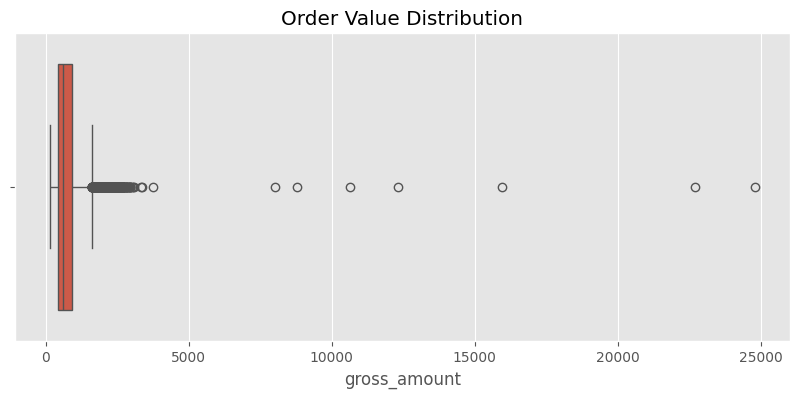

In [28]:
# ============================================================
# ORDER VALUE OUTLIERS
# ============================================================

plt.figure(figsize=(10,4))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title("Order Value Distribution")
plt.show()

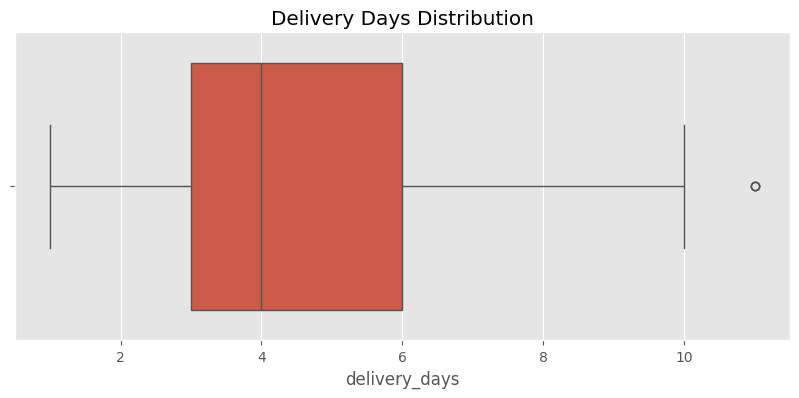

In [29]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=orders["delivery_days"]
)

plt.title("Delivery Days Distribution")
plt.show()

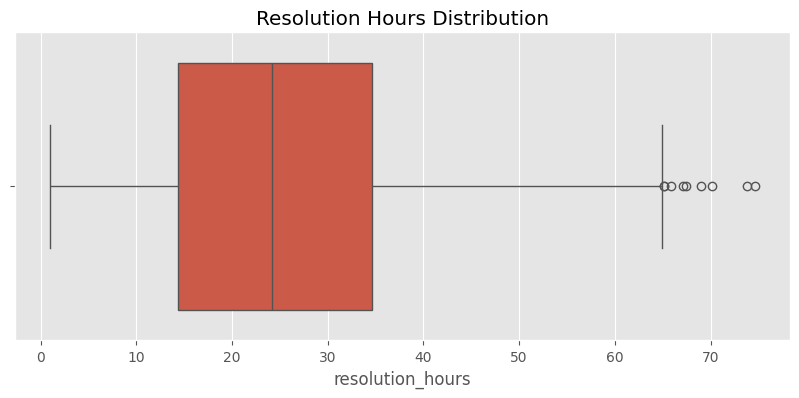

In [30]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=support_tickets["resolution_hours"]
)

plt.title("Resolution Hours Distribution")
plt.show()

# Join-Key Audit

### Objective

The project contains multiple datasets describing customer behaviour from different business perspectives.

To combine information correctly, it is important to verify that join keys are present, unique where expected, and consistent across datasets.

In this section, I audit the customer identifiers used for joining datasets and identify any potential issues that may affect downstream analysis.

The primary join key expected across datasets is:

**customer_id**

In [31]:
# ============================================================
# VERIFY CUSTOMER_ID EXISTS IN ALL DATASETS
# ============================================================

datasets = {
    "customers": customers,
    "orders": orders,
    "support_tickets": support_tickets,
    "web_events": web_events,
    "churn_labels": churn_labels,
    "intervention_history": intervention_history,
    "rfm_snapshot": rfm_snapshot
}

for name, df in datasets.items():

    print(f"{name}: ", "customer_id" in df.columns)

customers:  True
orders:  True
support_tickets:  True
web_events:  True
churn_labels:  True
intervention_history:  True
rfm_snapshot:  True


### Checking Customer ID Uniqueness

Some datasets should contain one row per customer, while others naturally contain multiple records per customer.

This check helps identify unexpected duplicates.

In [32]:
# ============================================================
# CUSTOMER_ID UNIQUENESS CHECK
# ============================================================

for name, df in datasets.items():

    unique_customers = df["customer_id"].nunique()

    total_rows = len(df)

    print("-" * 60)
    print(name.upper())

    print("Rows:", total_rows)
    print("Unique Customers:", unique_customers)

    print("Duplicate Customer Records:",
          total_rows - unique_customers)

------------------------------------------------------------
CUSTOMERS
Rows: 2400
Unique Customers: 2400
Duplicate Customer Records: 0
------------------------------------------------------------
ORDERS
Rows: 10009
Unique Customers: 2400
Duplicate Customer Records: 7609
------------------------------------------------------------
SUPPORT_TICKETS
Rows: 1921
Unique Customers: 1247
Duplicate Customer Records: 674
------------------------------------------------------------
WEB_EVENTS
Rows: 2400
Unique Customers: 2400
Duplicate Customer Records: 0
------------------------------------------------------------
CHURN_LABELS
Rows: 2400
Unique Customers: 2400
Duplicate Customer Records: 0
------------------------------------------------------------
INTERVENTION_HISTORY
Rows: 2400
Unique Customers: 2400
Duplicate Customer Records: 0
------------------------------------------------------------
RFM_SNAPSHOT
Rows: 2400
Unique Customers: 2400
Duplicate Customer Records: 0


### Checking Customer Coverage Across Datasets

Not every customer may appear in every dataset.

For example:

- some customers may never raise support tickets,
- some customers may never receive interventions,
- some customers may not generate web activity.

This audit identifies customer coverage differences.

In [33]:
# ============================================================
# CUSTOMER COVERAGE AUDIT
# ============================================================

master_customers = set(customers["customer_id"])

for name, df in datasets.items():

    dataset_customers = set(df["customer_id"])

    missing_customers = (
        master_customers -
        dataset_customers
    )

    print("\n")
    print("=" * 80)
    print(name.upper())

    print(
        "Customers Missing From Dataset:",
        len(missing_customers)
    )



CUSTOMERS
Customers Missing From Dataset: 0


ORDERS
Customers Missing From Dataset: 0


SUPPORT_TICKETS
Customers Missing From Dataset: 1153


WEB_EVENTS
Customers Missing From Dataset: 0


CHURN_LABELS
Customers Missing From Dataset: 0


INTERVENTION_HISTORY
Customers Missing From Dataset: 0


RFM_SNAPSHOT
Customers Missing From Dataset: 0


### Observation

The join-key audit confirms whether customer identifiers are consistently available across datasets.

Any missing customer records identified above should be considered during later data integration steps to avoid accidental row loss during joins.

# Date Consistency Audit

### Objective

Customer behaviour is time dependent.

Incorrect date values can lead to inaccurate recency calculations, feature engineering errors, and misleading business conclusions.

In this section, I verify that all date fields are properly formatted and logically consistent.

In [34]:
# ============================================================
# CONVERT DATE COLUMNS
# ============================================================

customers["signup_date"] = pd.to_datetime(
    customers["signup_date"]
)

orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

support_tickets["ticket_date"] = pd.to_datetime(
    support_tickets["ticket_date"]
)

web_events["snapshot_date"] = pd.to_datetime(
    web_events["snapshot_date"]
)

churn_labels["snapshot_date"] = pd.to_datetime(
    churn_labels["snapshot_date"]
)

intervention_history["snapshot_date"] = pd.to_datetime(
    intervention_history["snapshot_date"]
)

rfm_snapshot["snapshot_date"] = pd.to_datetime(
    rfm_snapshot["snapshot_date"]
)

print("Date conversion completed.")

Date conversion completed.


### Checking Date Ranges

This step helps identify unusual or unrealistic dates.

In [35]:
# ============================================================
# DATE RANGE AUDIT
# ============================================================

date_columns = {

    "customers":
        customers["signup_date"],

    "orders":
        orders["order_date"],

    "support_tickets":
        support_tickets["ticket_date"],

    "web_events":
        web_events["snapshot_date"],

    "churn_labels":
        churn_labels["snapshot_date"],

    "intervention_history":
        intervention_history["snapshot_date"],

    "rfm_snapshot":
        rfm_snapshot["snapshot_date"]
}

for name, column in date_columns.items():

    print("=" * 60)

    print(name.upper())

    print(
        "Minimum Date:",
        column.min()
    )

    print(
        "Maximum Date:",
        column.max()
    )

CUSTOMERS
Minimum Date: 2024-01-01 00:00:00
Maximum Date: 2025-09-15 00:00:00
ORDERS
Minimum Date: 2024-01-09 00:00:00
Maximum Date: 2025-11-29 00:00:00
SUPPORT_TICKETS
Minimum Date: 2024-01-13 00:00:00
Maximum Date: 2025-09-30 00:00:00
WEB_EVENTS
Minimum Date: 2025-09-30 00:00:00
Maximum Date: 2025-09-30 00:00:00
CHURN_LABELS
Minimum Date: 2025-09-30 00:00:00
Maximum Date: 2025-09-30 00:00:00
INTERVENTION_HISTORY
Minimum Date: 2025-09-30 00:00:00
Maximum Date: 2025-09-30 00:00:00
RFM_SNAPSHOT
Minimum Date: 2025-09-30 00:00:00
Maximum Date: 2025-09-30 00:00:00


### Checking for Future Dates

Future dates may indicate data-entry errors or system issues.

In [36]:
# ============================================================
# FUTURE DATE AUDIT
# ============================================================

today = pd.Timestamp.today()

print(
    "Orders with Future Dates:",
    (orders["order_date"] > today).sum()
)

print(
    "Support Tickets with Future Dates:",
    (support_tickets["ticket_date"] > today).sum()
)

print(
    "Customer Signups with Future Dates:",
    (customers["signup_date"] > today).sum()
)

Orders with Future Dates: 0
Support Tickets with Future Dates: 0
Customer Signups with Future Dates: 0


### Observation

The date audit helps ensure that customer activity follows a realistic timeline.

Any future dates, unusually old records, or inconsistent time periods should be reviewed before modeling or business analysis.

# Data Leakage Assessment

### Objective

Data leakage occurs when information unavailable at prediction time is used during analysis or model development.

Leakage can produce unrealistically high performance and lead to incorrect business decisions.

This section identifies variables that may create leakage risk if used incorrectly in future modeling tasks.

In [37]:
# ============================================================
# IDENTIFY POTENTIAL LEAKAGE COLUMNS
# ============================================================

potential_leakage = {

    "churn_labels": [
        "churn_next_60d"
    ],

    "rfm_snapshot": [
        "churn_next_60d"
    ],

    "intervention_history": [
        "last_campaign_received"
    ]
}

for dataset, columns in potential_leakage.items():

    print("=" * 60)

    print(dataset.upper())

    for col in columns:

        print(col)

CHURN_LABELS
churn_next_60d
RFM_SNAPSHOT
churn_next_60d
INTERVENTION_HISTORY
last_campaign_received


### Leakage Risk Discussion

Potential leakage columns identified:

1. **churn_next_60d**
   - This is the target variable itself.
   - Using it as an input feature would invalidate any predictive analysis.

2. **last_campaign_received**
   - Campaign interventions may occur after churn risk has already been identified.
   - Improper use could leak future business actions into the analysis.

3. **snapshot_date**
   - Must be handled carefully during train-test splitting.
   - Mixing future and past observations can introduce temporal leakage.

These columns should either be excluded or carefully controlled during later modeling stages.

In [38]:
# ============================================================
# IQR OUTLIER COUNTS
# EXTRA ANALYSIS
# ============================================================

def count_outliers(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return ((series < lower) | (series > upper)).sum()

print(
    "Gross Amount Outliers:",
    count_outliers(orders["gross_amount"])
)

print(
    "Delivery Day Outliers:",
    count_outliers(orders["delivery_days"])
)

print(
    "Resolution Hour Outliers:",
    count_outliers(
        support_tickets["resolution_hours"]
    )
)

Gross Amount Outliers: 536
Delivery Day Outliers: 3
Resolution Hour Outliers: 9


# Preliminary Business Understanding

Before beginning exploratory analysis, it is useful to understand the business meaning of each dataset and how they relate to customer churn.

The available datasets collectively describe:

- Customer demographics
- Purchase behaviour
- Customer support interactions
- Website/app engagement
- Marketing interventions
- Churn outcomes

Together, these datasets provide a comprehensive view of the customer lifecycle and enable identification of churn-risk patterns.

# Exploratory Data Analysis

## Customer Demographics & Profile Analysis

### Objective

Understanding customer demographics is important because customer characteristics often influence purchasing behaviour, engagement levels, and retention outcomes.

In this section, I explore:

- Age Groups
- City Tiers
- Acquisition Channels
- Loyalty Tiers
- Product Preferences

### Age Group Distribution

This chart shows the composition of customers across different age groups.

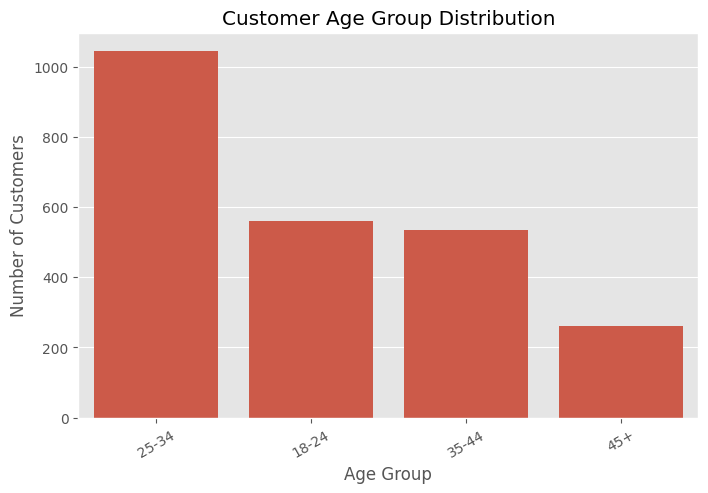

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="age_group",
    order=customers["age_group"].value_counts().index
)

plt.title("Customer Age Group Distribution")

plt.xlabel("Age Group")

plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

### Observation

This chart shows which age segments dominate the customer base.

If a particular age group contributes a disproportionately large share of customers, future retention efforts may need to focus specifically on that segment.

Age groups with relatively small representation may indicate potential growth opportunities or underserved customer segments.

### City Tier Distribution

This analysis helps understand the geographical distribution of customers.

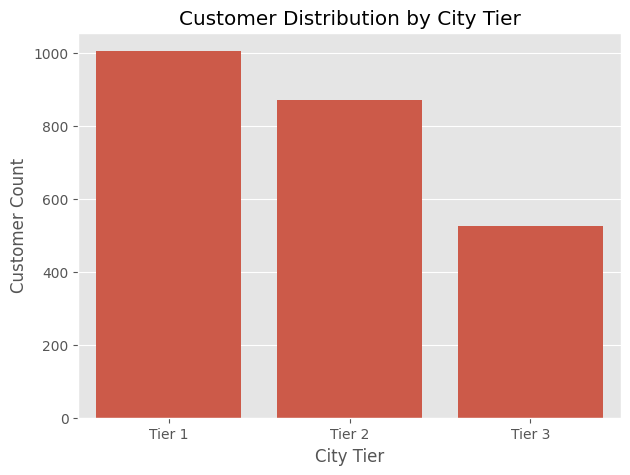

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=customers,
    x="city_tier",
    order=customers["city_tier"].value_counts().index
)

plt.title("Customer Distribution by City Tier")

plt.xlabel("City Tier")

plt.ylabel("Customer Count")

plt.show()

### Observation

Customer concentration across city tiers provides insight into market penetration.

Differences across tiers may later help explain churn behaviour, purchasing frequency, and engagement patterns.

### Customer Acquisition Channels

Understanding acquisition channels helps evaluate which marketing sources are bringing customers into the business.

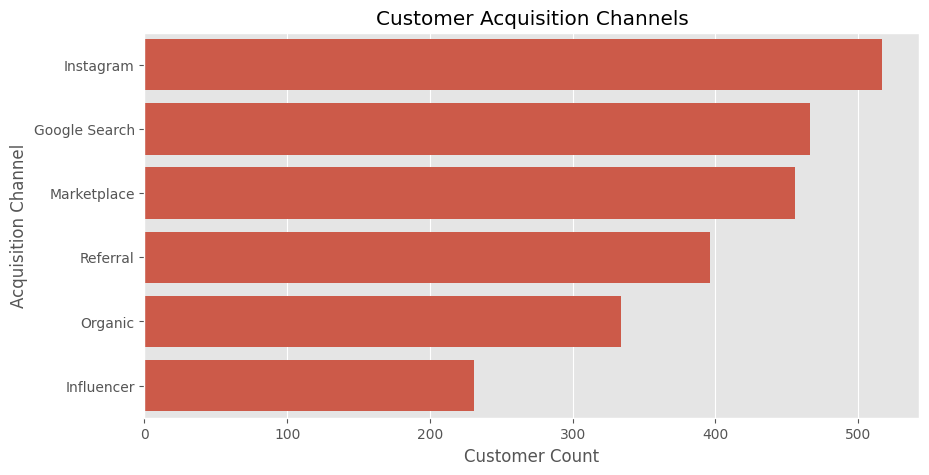

In [41]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=customers,
    y="acquisition_channel",
    order=customers["acquisition_channel"].value_counts().index
)

plt.title("Customer Acquisition Channels")

plt.xlabel("Customer Count")

plt.ylabel("Acquisition Channel")

plt.show()

### Observation

Acquisition channels often differ significantly in customer quality and retention.

A channel contributing many customers may not necessarily contribute high-value or loyal customers.

Further churn analysis will help determine whether certain acquisition sources are associated with elevated churn risk.

### Loyalty Tier Distribution

Loyalty programs are designed to improve customer retention and engagement.

This analysis examines the distribution of customers across loyalty tiers.

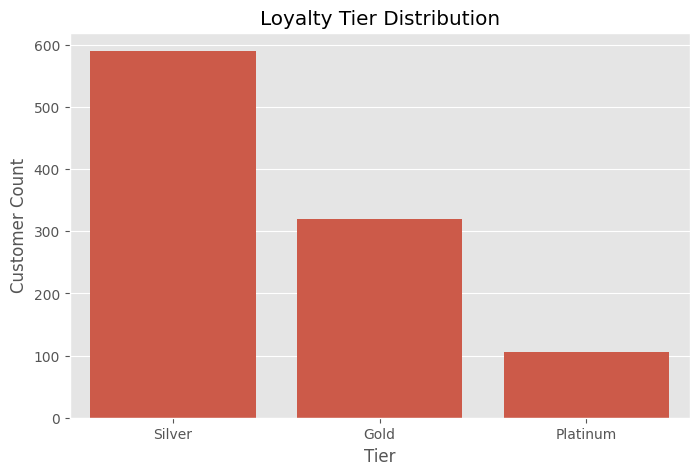

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="loyalty_tier",
    order=customers["loyalty_tier"].value_counts().index
)

plt.title("Loyalty Tier Distribution")

plt.xlabel("Tier")

plt.ylabel("Customer Count")

plt.show()

### Observation

A larger share of customers in higher loyalty tiers may indicate successful retention efforts.

Conversely, if most customers remain in lower tiers, the business may need stronger loyalty engagement strategies.

### Preferred Product Categories

Customer category preferences provide insight into purchasing interests and business revenue drivers.

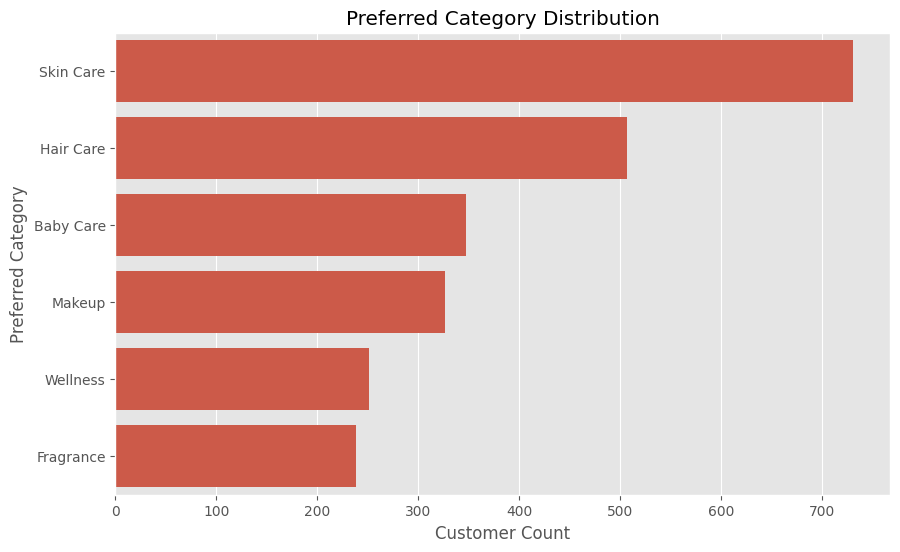

In [43]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=customers,
    y="preferred_category",
    order=customers["preferred_category"].value_counts().index
)

plt.title("Preferred Category Distribution")

plt.xlabel("Customer Count")

plt.ylabel("Preferred Category")

plt.show()

### Observation

The preferred category distribution reveals the product categories attracting the greatest customer interest.

Understanding category preferences is useful for targeted marketing and personalized retention campaigns.

### Customer Acquisition Trend Over Time

Analyzing signup patterns helps understand customer growth trends.

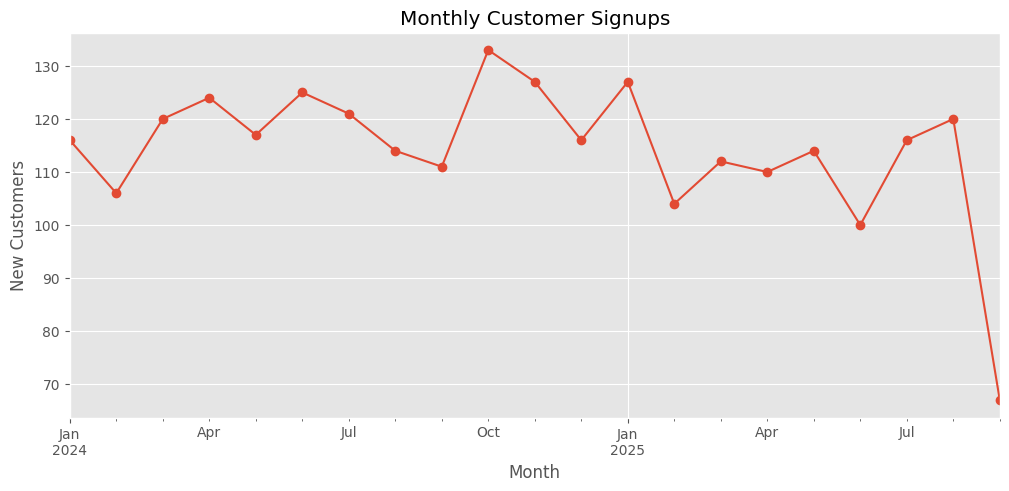

In [44]:
customers["signup_year_month"] = (
    customers["signup_date"]
    .dt.to_period("M")
)

monthly_signup = (
    customers
    .groupby("signup_year_month")
    .size()
)

monthly_signup.plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Monthly Customer Signups")

plt.xlabel("Month")

plt.ylabel("New Customers")

plt.grid(True)

plt.show()

# Order Behaviour Analysis

## Objective

Customer ordering patterns often provide early indicators of customer satisfaction, engagement, and future retention.

In this section, I analyze:

- Order volume
- Product category purchases
- Delivery performance
- Ratings
- Purchase quantities
- Customer purchase frequency

The goal is to identify behavioural patterns that may later help explain customer churn.

### Preparing Order Dataset

Before beginning the analysis, I am creating a few helper variables that will make it easier to study customer purchase behaviour.

In [45]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


### Product Category Distribution

This analysis shows which product categories contribute the highest volume of orders.

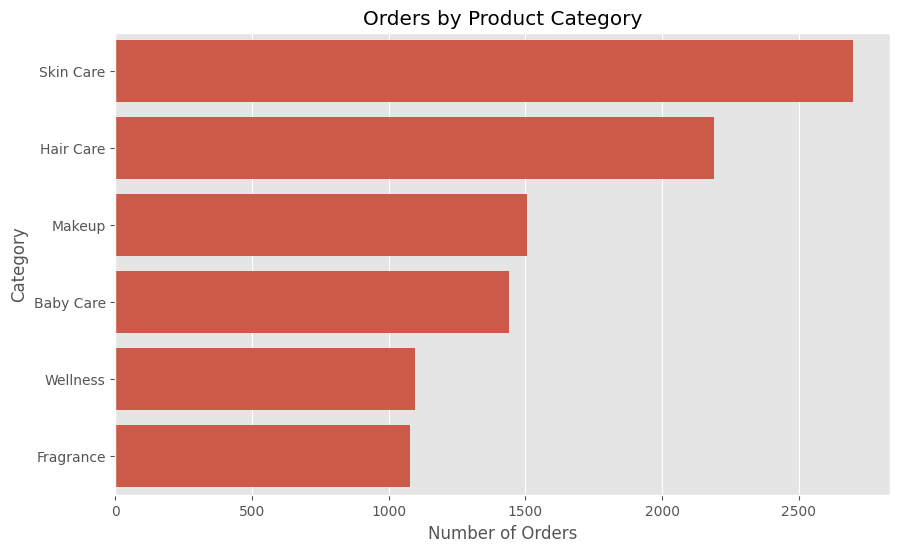

In [46]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=orders,
    y="category",
    order=orders["category"].value_counts().index
)

plt.title("Orders by Product Category")

plt.xlabel("Number of Orders")
plt.ylabel("Category")

plt.show()

### Observation

The chart highlights customer demand across product categories.

Categories receiving significantly higher order volumes may represent core business segments, while low-volume categories may require further investigation to understand customer interest and engagement.

### Quantity Purchased Per Order

This analysis evaluates how many units customers typically purchase in a single transaction.

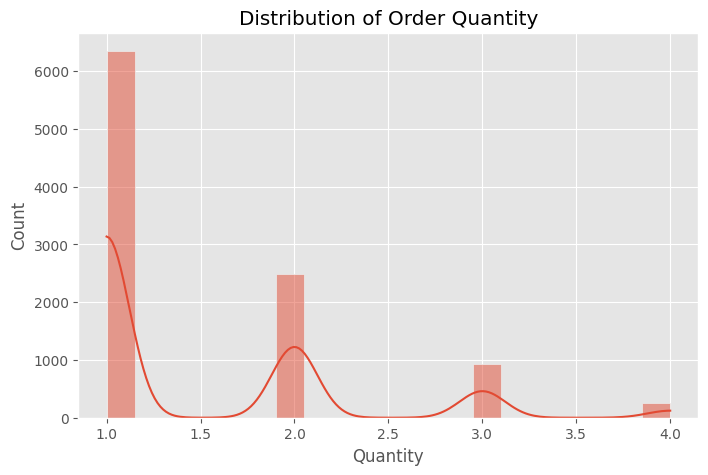

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders["quantity"],
    bins=20,
    kde=True
)

plt.title("Distribution of Order Quantity")

plt.xlabel("Quantity")

plt.show()

### Observation

The quantity distribution helps identify common purchasing behaviour.

Large variations may indicate the presence of both casual buyers and high-volume customers.

### Delivery Time Analysis

Delivery performance plays an important role in customer satisfaction and retention.

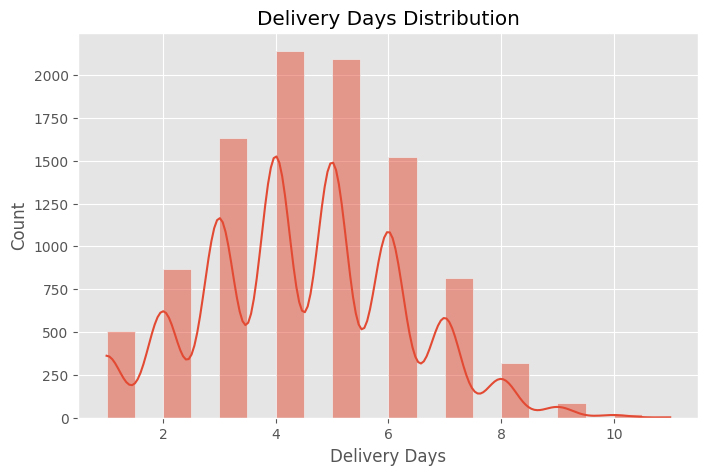

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders["delivery_days"],
    bins=20,
    kde=True
)

plt.title("Delivery Days Distribution")

plt.xlabel("Delivery Days")

plt.show()

### Observation

Long delivery times may negatively affect customer experience.

The distribution helps identify whether delivery delays are common or limited to a small subset of orders.

### Bonus Analysis: Delivery Outliers

This boxplot helps identify unusually delayed deliveries.

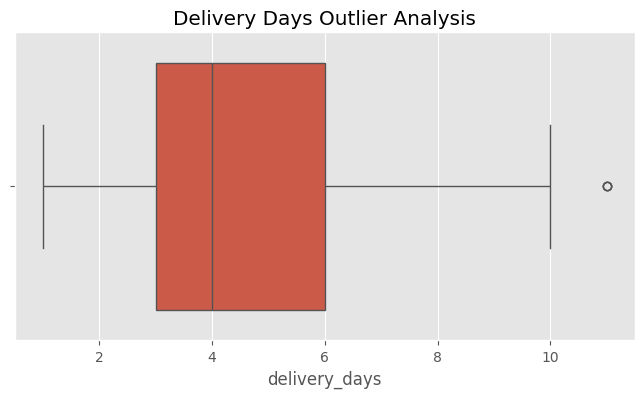

In [49]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=orders["delivery_days"]
)

plt.title("Delivery Days Outlier Analysis")

plt.show()

### Customer Ratings

Ratings provide a direct measure of customer satisfaction.

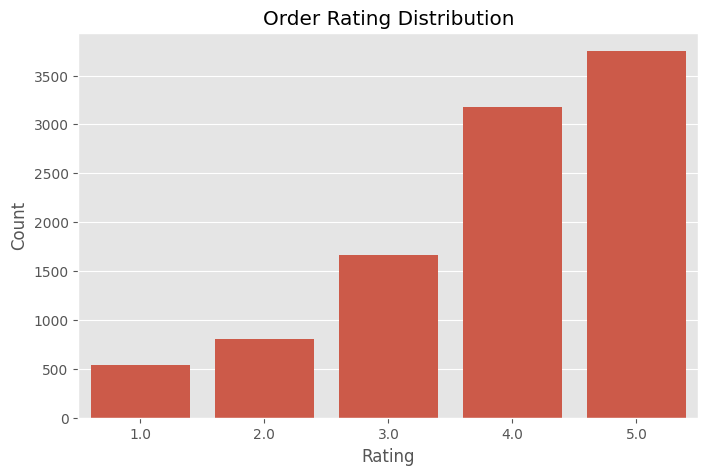

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x="rating"
)

plt.title("Order Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

### Observation

Ratings provide insight into overall customer sentiment.

Lower ratings may later emerge as an important indicator of churn risk.

### Gross Order Amount Distribution

This analysis examines how much customers spend per transaction.

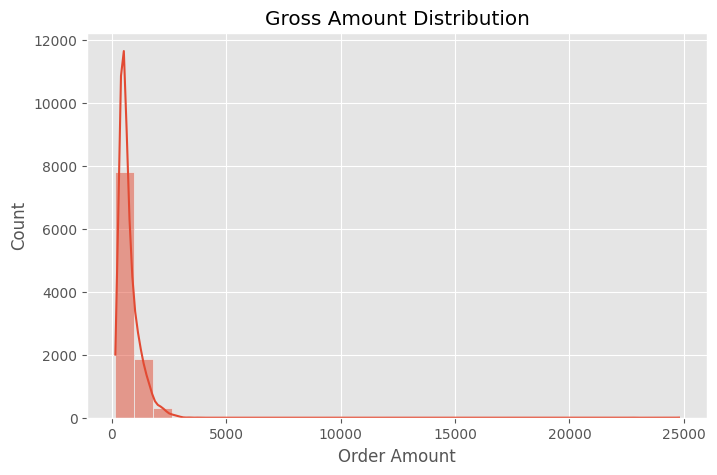

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders["gross_amount"],
    bins=30,
    kde=True
)

plt.title("Gross Amount Distribution")

plt.xlabel("Order Amount")

plt.show()

### Observation

The spending distribution helps distinguish low-value and high-value transactions.

Understanding spending behaviour is important for later retention prioritization.

### Revenue Contribution by Category

This analysis identifies which categories generate the most revenue.

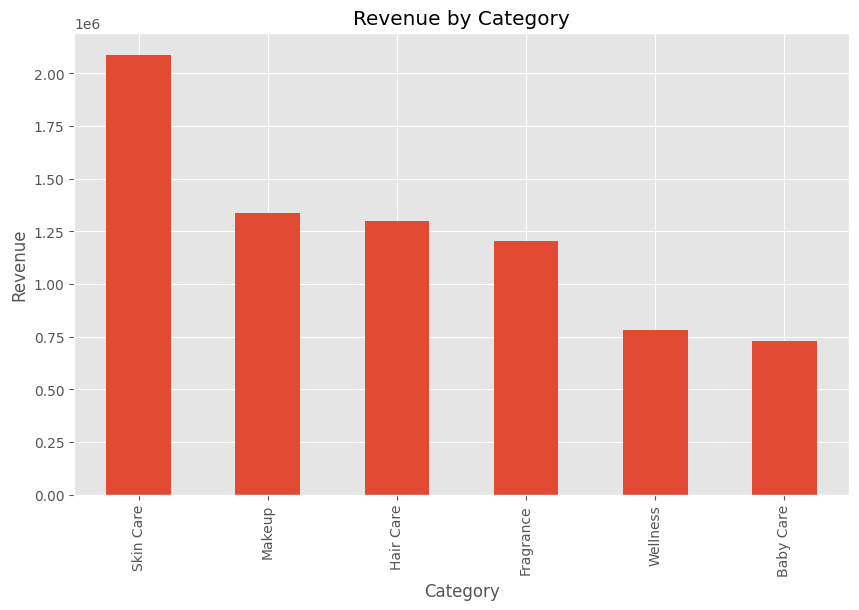

In [52]:
category_revenue = (
    orders
    .groupby("category")["gross_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.show()

### Observation

Revenue contribution often differs from order volume.

Some categories may generate fewer orders but significantly higher revenue.

### Discount Percentage Analysis

This chart examines how discounts are distributed across customer purchases.

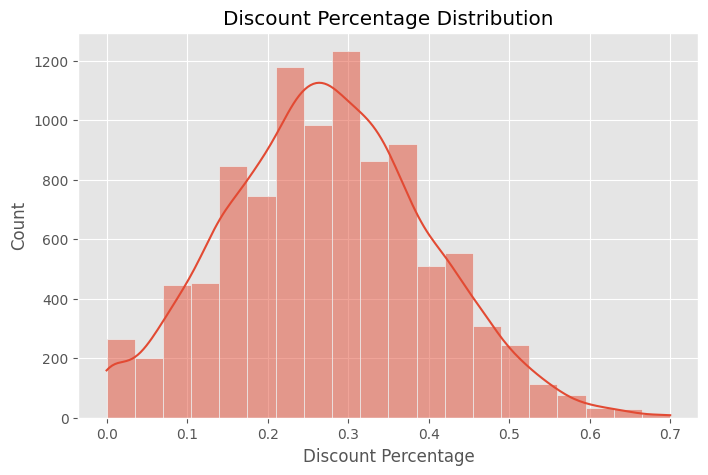

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders["discount_pct"],
    bins=20,
    kde=True
)

plt.title("Discount Percentage Distribution")

plt.xlabel("Discount Percentage")

plt.show()

### Observation

Heavy discount dependence may indicate price-sensitive customer behaviour.

Such customers can sometimes be more vulnerable to churn when promotional activity decreases.

### Orders Per Customer

This analysis measures customer purchasing frequency.

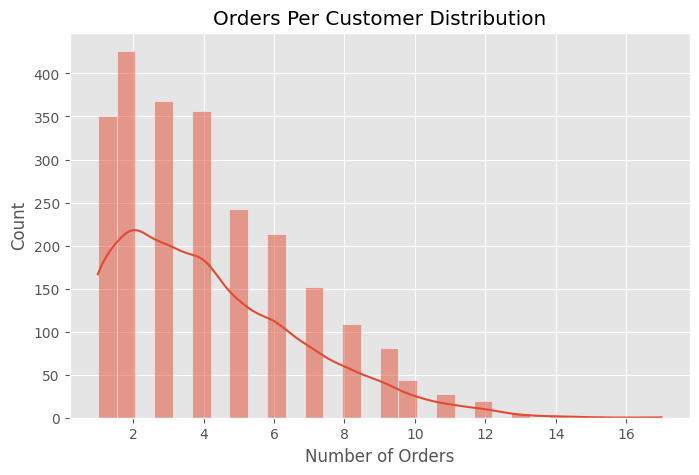

In [54]:
orders_per_customer = (
    orders
    .groupby("customer_id")
    .size()
)

plt.figure(figsize=(8,5))

sns.histplot(
    orders_per_customer,
    bins=30,
    kde=True
)

plt.title("Orders Per Customer Distribution")

plt.xlabel("Number of Orders")

plt.show()

### Observation

Customers with very low order frequency may represent one-time buyers or weakly engaged customers.

Customers with high order frequency often indicate stronger brand loyalty and engagement.

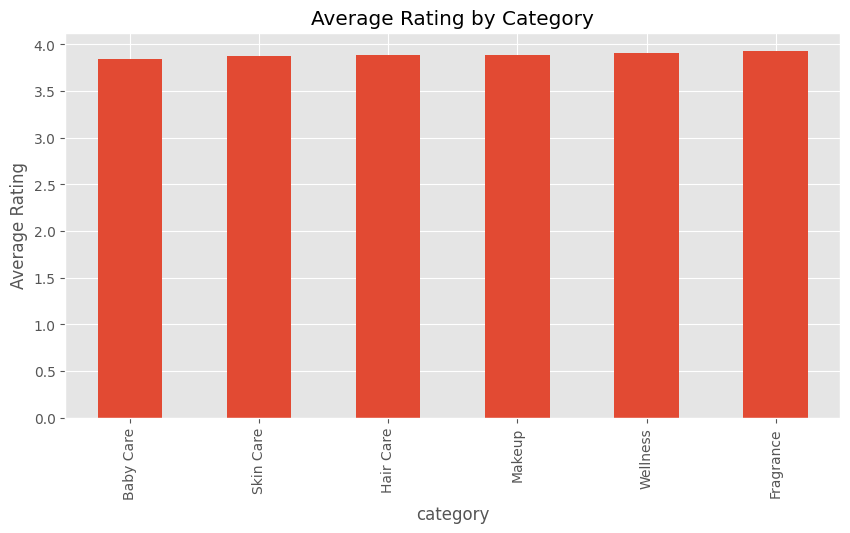

In [55]:
avg_rating = (
    orders
    .groupby("category")["rating"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))

avg_rating.plot(kind="bar")

plt.title("Average Rating by Category")

plt.ylabel("Average Rating")

plt.show()

# Monetary Behaviour Analysis

## Objective

Customer spending behaviour is one of the strongest indicators of customer value and long-term business impact.

In this section, I analyze:

- Customer spending patterns
- Revenue concentration
- Spending segments
- Revenue contribution across loyalty tiers
- Customer lifetime value indicators

The purpose is to understand how customer monetary behaviour varies and identify groups that may require targeted retention strategies.

### Creating Customer-Level Spending Metrics

To analyze monetary behaviour, I first aggregate order-level data into customer-level spending statistics.

In [56]:
customer_spend = (
    orders
    .groupby("customer_id")
    .agg({
        "gross_amount": ["sum","mean","count"],
        "discount_pct": "mean"
    })
)

customer_spend.columns = [
    "total_spend",
    "avg_order_value",
    "order_count",
    "avg_discount_pct"
]

customer_spend = customer_spend.reset_index()

customer_spend.head()

,customer_id,total_spend,avg_order_value,order_count,avg_discount_pct
0,CUST00001,2955.57,492.595000,6,0.363333
1,CUST00002,1713.10,571.033333,3,0.190000
2,CUST00003,649.98,649.980000,1,0.470000
3,CUST00004,1604.04,1604.040000,1,0.160000
4,CUST00005,3910.43,651.738333,6,0.388333


### Total Customer Spend Distribution

This analysis examines how spending is distributed across customers.

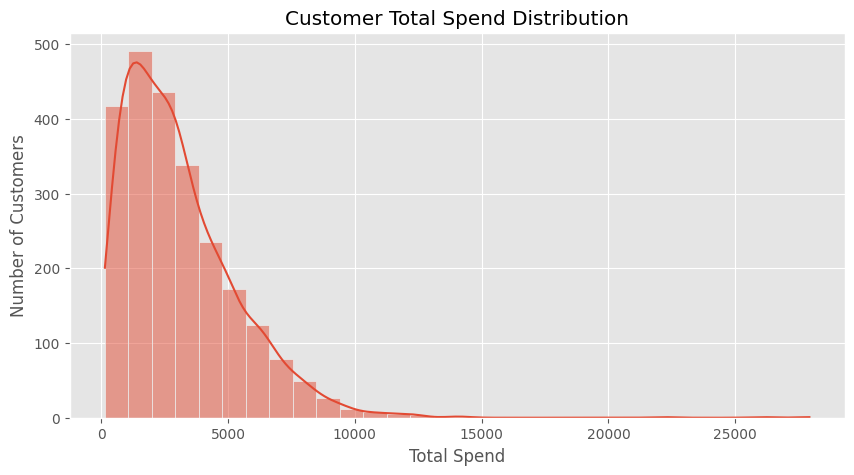

In [57]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_spend["total_spend"],
    bins=30,
    kde=True
)

plt.title("Customer Total Spend Distribution")

plt.xlabel("Total Spend")

plt.ylabel("Number of Customers")

plt.show()

### Observation

Most businesses typically have a small group of high-value customers and a larger group of lower-value customers.

Understanding this distribution helps identify revenue concentration and retention priorities.

### Average Order Value Analysis

Average order value helps understand purchasing power and spending behaviour.

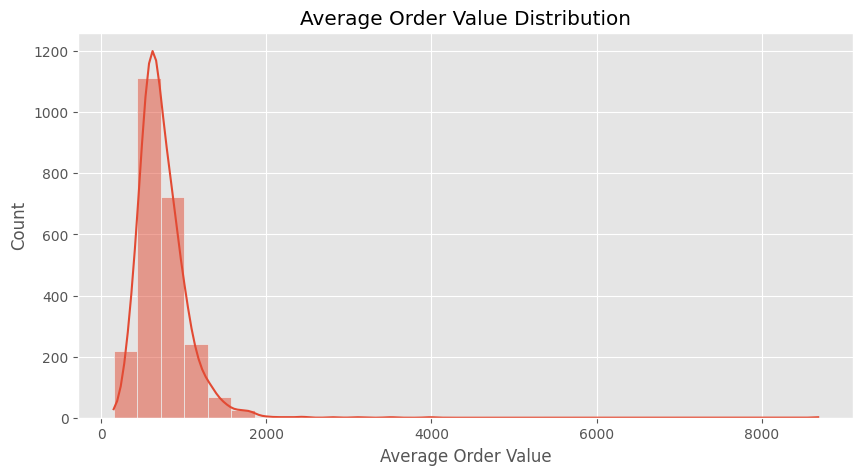

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_spend["avg_order_value"],
    bins=30,
    kde=True
)

plt.title("Average Order Value Distribution")

plt.xlabel("Average Order Value")

plt.show()

### Observation

Customers with higher average order values may represent premium customer segments.

Retaining these customers often has a disproportionately large impact on revenue.

### Spending Segmentation

Customers are grouped into spending quartiles to understand different value segments.

In [59]:
customer_spend["spending_segment"] = pd.qcut(
    customer_spend["total_spend"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Premium Value"
    ]
)

customer_spend["spending_segment"].value_counts()

spending_segment
Low Value        600
Medium Value     600
High Value       600
Premium Value    600
Name: count, dtype: int64

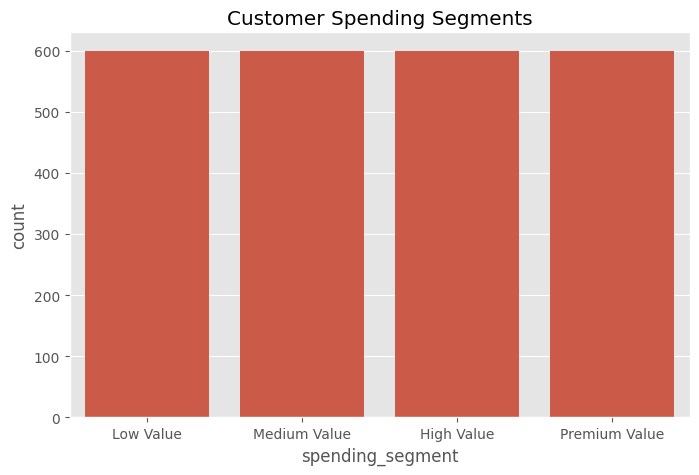

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_spend,
    x="spending_segment",
    order=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Premium Value"
    ]
)

plt.title("Customer Spending Segments")

plt.show()

### Observation

Segmenting customers based on spending allows the business to prioritize retention resources more effectively.

Premium-value customers may require specialized retention strategies.

### Bonus Analysis: Revenue Concentration

This analysis measures how much revenue is generated by the highest-spending customers.

In [61]:
customer_spend_sorted = customer_spend.sort_values(
    by="total_spend",
    ascending=False
)

top_10_pct = int(len(customer_spend_sorted) * 0.10)

top_revenue = (
    customer_spend_sorted
    .head(top_10_pct)["total_spend"]
    .sum()
)

overall_revenue = customer_spend_sorted["total_spend"].sum()

revenue_share = (
    top_revenue / overall_revenue
) * 100

print(
    f"Top 10% customers contribute {revenue_share:.2f}% of total revenue"
)

Top 10% customers contribute 25.71% of total revenue


### Observation

A very high revenue concentration indicates dependency on a relatively small customer group.

Losing even a small number of these customers could significantly impact business performance.

### Revenue by Loyalty Tier

This analysis investigates whether loyalty tiers correspond to higher revenue contribution.

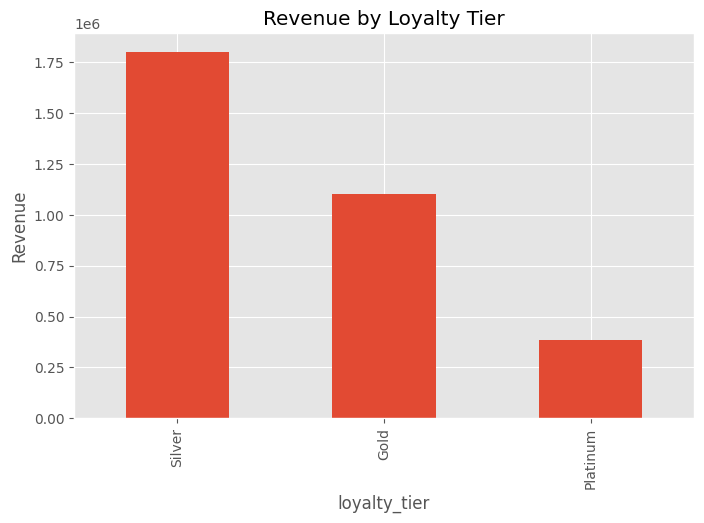

In [62]:
customer_revenue = (
    orders
    .groupby("customer_id")["gross_amount"]
    .sum()
    .reset_index()
)

revenue_loyalty = customer_revenue.merge(
    customers[
        ["customer_id","loyalty_tier"]
    ],
    on="customer_id",
    how="left"
)

tier_revenue = (
    revenue_loyalty
    .groupby("loyalty_tier")["gross_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

tier_revenue.plot(kind="bar")

plt.title("Revenue by Loyalty Tier")

plt.ylabel("Revenue")

plt.show()

### Observation

Higher loyalty tiers are generally expected to generate greater revenue.

If this relationship is weak, it may indicate opportunities to improve loyalty program effectiveness.

### Highest Revenue Customers

This analysis identifies the most valuable customers in the dataset.

In [63]:
top_customers = (
    customer_spend
    .sort_values(
        by="total_spend",
        ascending=False
    )
    .head(20)
)

display(top_customers)

,customer_id,total_spend,avg_order_value,order_count,avg_discount_pct,spending_segment
210,CUST00211,27920.05,3988.578571,7,0.317143,Premium Value
1867,CUST01868,26057.29,8685.763333,3,0.216667,Premium Value
2105,CUST02106,22131.36,2459.040000,9,0.295556,Premium Value
271,CUST00272,14120.16,1008.582857,14,0.231429,Premium Value
1987,CUST01988,14032.75,3508.187500,4,0.130000,Premium Value
1294,CUST01295,12408.61,3102.152500,4,0.155000,Premium Value
2153,CUST02154,12407.64,729.861176,17,0.186471,Premium Value
1359,CUST01360,12310.69,1538.836250,8,0.395000,Premium Value
816,CUST00817,12291.02,819.401333,15,0.309333,Premium Value
990,CUST00991,11918.47,993.205833,12,0.226667,Premium Value


### Observation

The top-spending customers represent a critical revenue-generating segment.

Future retention strategies should pay particular attention to preserving relationships with these customers.

### Bonus Feature: Revenue Per Order

This derived metric measures average spending efficiency for each customer.

In [64]:
customer_spend["revenue_per_order"] = (
    customer_spend["total_spend"]
    /
    customer_spend["order_count"]
)

customer_spend[
    [
        "customer_id",
        "revenue_per_order"
    ]
].head()

,customer_id,revenue_per_order
0,CUST00001,492.595000
1,CUST00002,571.033333
2,CUST00003,649.980000
3,CUST00004,1604.040000
4,CUST00005,651.738333


# Support Ticket Analysis

## Objective

Customer support interactions provide valuable insight into customer satisfaction and operational performance.

Repeated complaints, unresolved issues, long resolution times, and negative customer sentiment may contribute to increased churn risk.

In this section, I analyze:

- Ticket volume
- Issue categories
- Resolution performance
- Ticket sentiment
- Reopened tickets
- Support channels

The goal is to understand how customer support behaviour may relate to future churn.

### Support Ticket Dataset Overview

Before analyzing support behaviour, I first review the overall ticket volume and customer coverage.

In [65]:
# ============================================================
# SUPPORT TICKET OVERVIEW
# ============================================================

print("Total Tickets:", len(support_tickets))

print(
    "Unique Customers Raising Tickets:",
    support_tickets["customer_id"].nunique()
)

Total Tickets: 1921
Unique Customers Raising Tickets: 1247


### Issue Type Distribution

Different issue categories may have different impacts on customer satisfaction.

This analysis identifies the most common support issues.

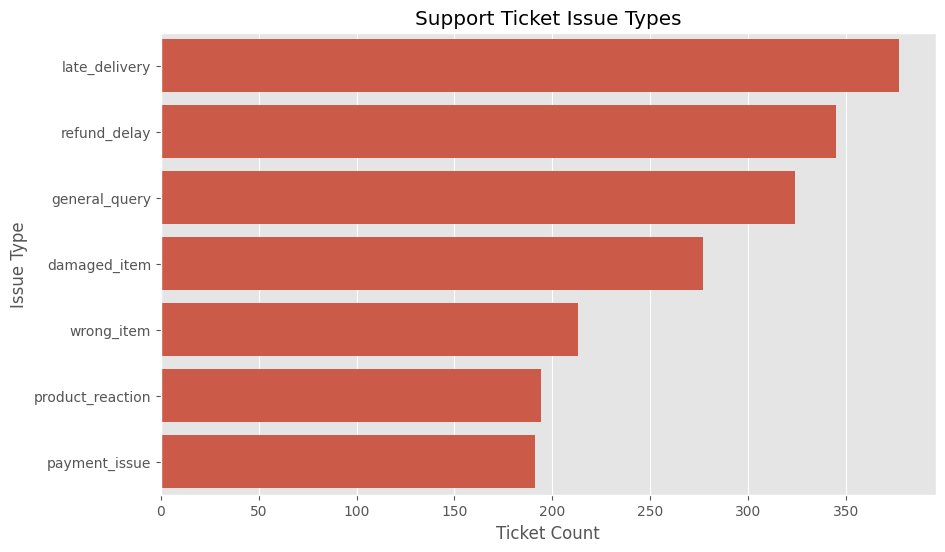

In [66]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=support_tickets,
    y="issue_type",
    order=support_tickets["issue_type"]
        .value_counts()
        .index
)

plt.title("Support Ticket Issue Types")

plt.xlabel("Ticket Count")
plt.ylabel("Issue Type")

plt.show()

### Observation

The issue-type distribution highlights the most common reasons customers contact support.

Issue categories with disproportionately high volumes may indicate recurring operational problems that require business attention.

### Resolution Time Distribution

Resolution time is an important indicator of customer service efficiency.

Long waiting periods may negatively affect customer experience.

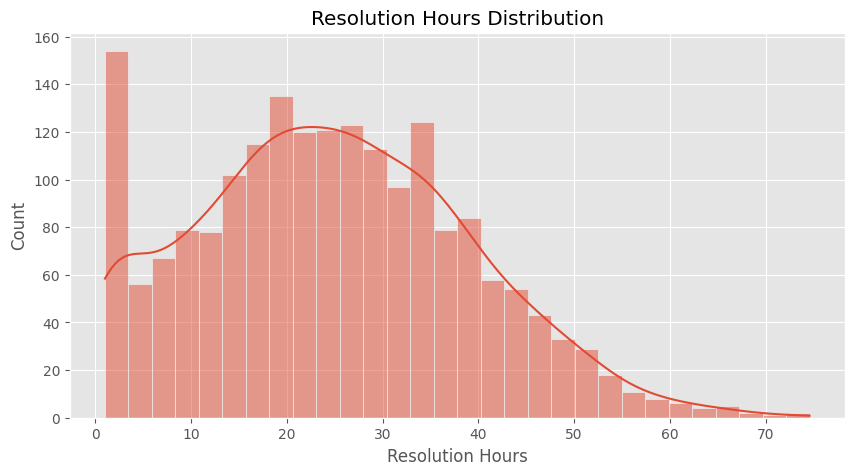

In [67]:
plt.figure(figsize=(10,5))

sns.histplot(
    support_tickets["resolution_hours"],
    bins=30,
    kde=True
)

plt.title("Resolution Hours Distribution")

plt.xlabel("Resolution Hours")

plt.show()

### Observation

Most support interactions should ideally be resolved quickly.

A long tail of unresolved or slow-resolution tickets may indicate operational bottlenecks and potential churn risk.

### Bonus Analysis: Resolution Time Outliers

This boxplot helps identify unusually long ticket resolution times.

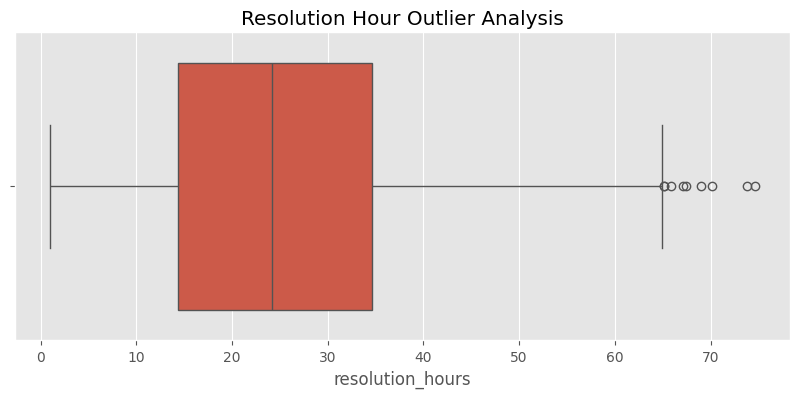

In [68]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=support_tickets["resolution_hours"]
)

plt.title("Resolution Hour Outlier Analysis")

plt.show()

### Sentiment Score Analysis

Sentiment scores provide a quantitative measure of customer satisfaction expressed during support interactions.

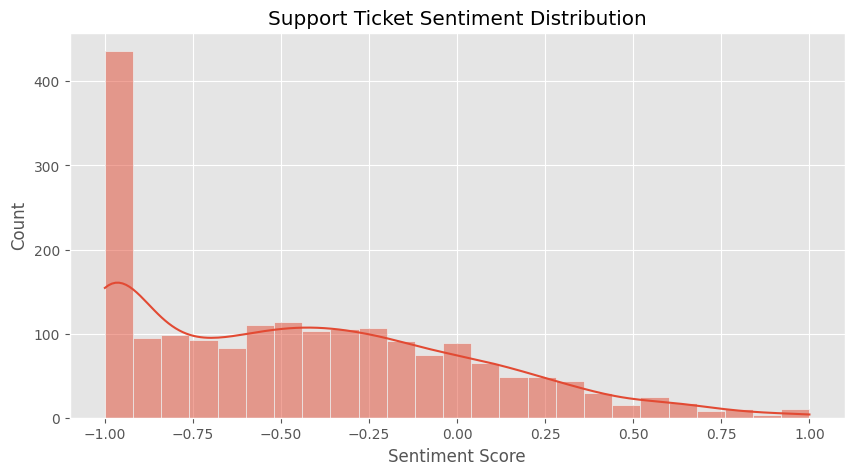

In [69]:
plt.figure(figsize=(10,5))

sns.histplot(
    support_tickets["sentiment_score"],
    bins=25,
    kde=True
)

plt.title("Support Ticket Sentiment Distribution")

plt.xlabel("Sentiment Score")

plt.show()

### Observation

Negative sentiment often reflects dissatisfaction with products, services, or support experiences.

Customers consistently expressing negative sentiment may require proactive retention efforts.

### Tickets Raised Per Customer

This analysis evaluates how frequently customers contact support.

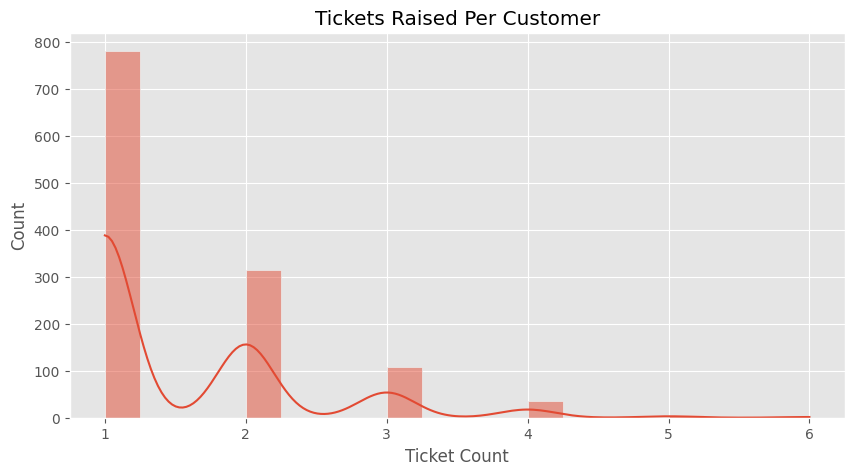

In [72]:
tickets_per_customer = (
    support_tickets
    .groupby("customer_id")
    .size()
)

plt.figure(figsize=(10,5))

sns.histplot(
    tickets_per_customer,
    bins=20,
    kde=True
)

plt.title("Tickets Raised Per Customer")

plt.xlabel("Ticket Count")

plt.show()

### Observation

Customers repeatedly contacting support may be experiencing recurring issues.

Frequent support interaction may later emerge as an important churn-risk indicator.

### Customers with Persistently Negative Sentiment

This analysis identifies customers who may be experiencing poor support experiences.

In [73]:
negative_customers = (
    support_tickets
    .groupby("customer_id")["sentiment_score"]
    .mean()
    .reset_index()
)

negative_customers = negative_customers.sort_values(
    by="sentiment_score"
)

negative_customers.head(20)

,customer_id,sentiment_score
1217,CUST02332,-1.0
2,CUST00005,-1.0
1209,CUST02321,-1.0
1238,CUST02384,-1.0
1139,CUST02182,-1.0
6,CUST00013,-1.0
1161,CUST02229,-1.0
1153,CUST02216,-1.0
94,CUST00195,-1.0
92,CUST00190,-1.0


### Observation

The customers listed above exhibit the lowest average sentiment scores.

These customers may warrant closer investigation during later churn-risk analysis and manual review exercises.

In [74]:
high_risk_support = (
    support_tickets
    .groupby("customer_id")
    .agg({
        "ticket_id":"count",
        "resolution_hours":"mean",
        "sentiment_score":"mean"
    })
)

high_risk_support.columns = [
    "ticket_count",
    "avg_resolution_hours",
    "avg_sentiment"
]

high_risk_support.sort_values(
    by=["ticket_count","avg_sentiment"],
    ascending=[False,True]
).head(20)

,ticket_count,avg_resolution_hours,avg_sentiment
customer_id,,,
CUST00042,6,12.000000,-0.455000
CUST00263,6,24.216667,-0.425000
CUST00487,6,20.833333,-0.308333
CUST01857,5,43.760000,-0.552000
CUST00617,5,33.220000,-0.426000
CUST01416,5,22.060000,-0.386000
CUST01115,5,31.280000,-0.288000
CUST01136,5,14.760000,-0.268000
CUST01581,5,21.780000,-0.150000


# Return and Refund Behaviour Analysis

## Objective

Product returns and refunds provide valuable insight into customer satisfaction and purchasing experience.

Frequent returns may indicate:

- Product quality issues
- Customer expectation mismatches
- Delivery-related problems
- Customer dissatisfaction

In this section, I analyze return behaviour and investigate its potential relationship with future churn.

## Return Behaviour Overview

This section examines the overall frequency of returned orders within the dataset.

In [76]:
# ============================================================
# RETURN BEHAVIOUR OVERVIEW
# ============================================================

print("Return Value Distribution")

display(
    orders["returned"].value_counts()
)

Return Value Distribution


returned
0    9334
1     675
Name: count, dtype: int64

### Returned vs Non-Returned Orders

This chart shows the proportion of returned and non-returned orders.

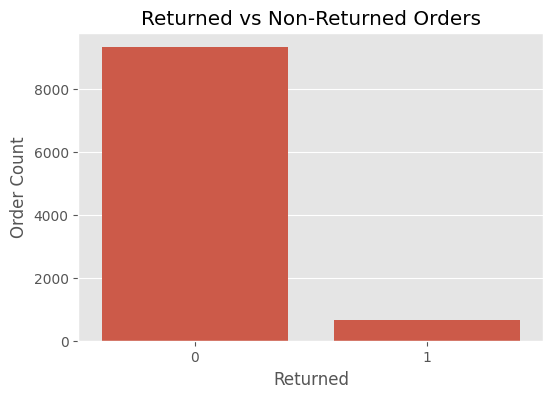

In [77]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=orders,
    x="returned"
)

plt.title("Returned vs Non-Returned Orders")

plt.xlabel("Returned")

plt.ylabel("Order Count")

plt.show()

### Observation

This chart provides an overview of return frequency across all orders.

A high proportion of returned orders may indicate customer dissatisfaction, product quality issues, or expectation mismatches.

### Overall Return Rate

This metric measures the percentage of all orders that were returned.

In [78]:
overall_return_rate = (
    orders["returned"].mean()
) * 100

print(
    f"Overall Return Rate: {overall_return_rate:.2f}%"
)

Overall Return Rate: 6.74%


### Observation

The overall return rate provides a baseline measure of product return behaviour across the business.

Higher return rates may increase operational costs and indicate customer dissatisfaction.

### Customer-Level Return Rate

This analysis evaluates how return behaviour varies across individual customers.

In [79]:
customer_returns = (
    orders
    .groupby("customer_id")["returned"]
    .mean()
    .reset_index()
)

customer_returns.columns = [
    "customer_id",
    "return_rate"
]

customer_returns.head()

,customer_id,return_rate
0,CUST00001,0.166667
1,CUST00002,0.000000
2,CUST00003,0.000000
3,CUST00004,0.000000
4,CUST00005,0.000000


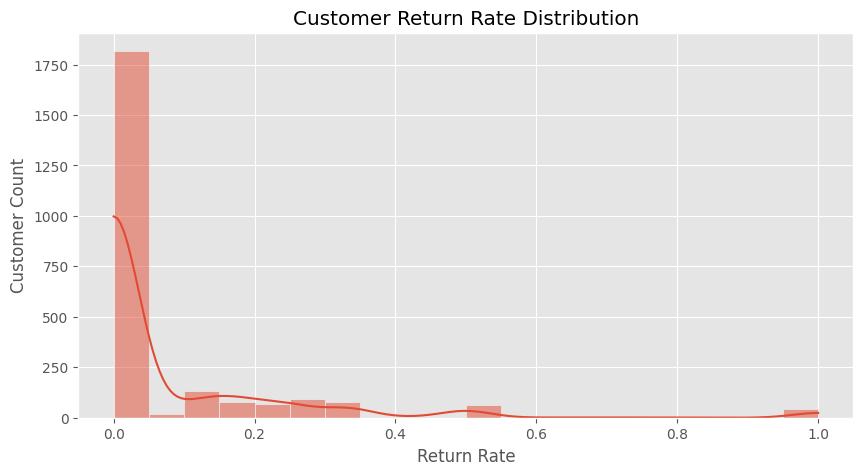

In [80]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_returns["return_rate"],
    bins=20,
    kde=True
)

plt.title("Customer Return Rate Distribution")

plt.xlabel("Return Rate")

plt.ylabel("Customer Count")

plt.show()

### Observation

Most customers are expected to have low return rates.

Customers with consistently high return rates may represent dissatisfied customers and could become important churn-risk candidates.

### Return Rate by Product Category

Different product categories often experience different return patterns.

This analysis identifies categories with elevated return behaviour.

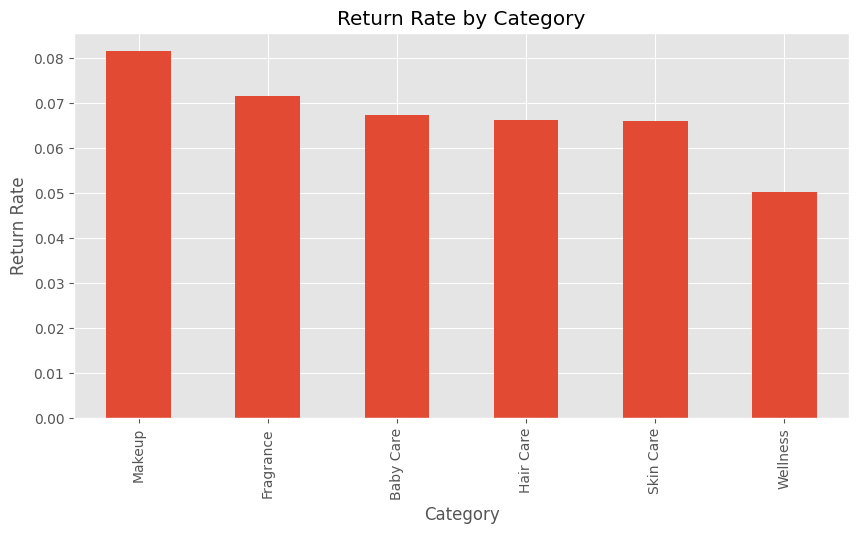

In [81]:
category_return_rate = (
    orders
    .groupby("category")["returned"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

category_return_rate.plot(
    kind="bar"
)

plt.title("Return Rate by Category")

plt.xlabel("Category")

plt.ylabel("Return Rate")

plt.show()

### Observation

Categories with higher return rates may indicate product quality issues, customer expectation mismatches, or category-specific challenges.

These categories may require additional business investigation.

### Relationship Between Returns and Customer Ratings

This analysis investigates whether returned products tend to receive lower ratings.

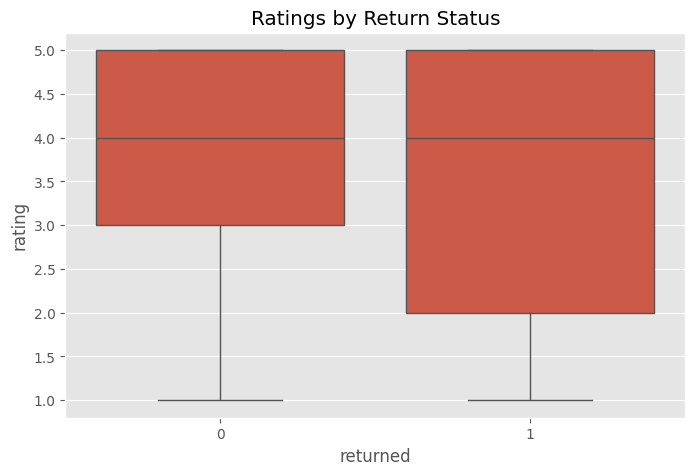

In [82]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=orders,
    x="returned",
    y="rating"
)

plt.title(
    "Ratings by Return Status"
)

plt.show()

### Observation

If returned products consistently receive lower ratings, this suggests customer dissatisfaction is contributing to return behaviour.

This pattern may later emerge as a churn-risk indicator.

### Bonus Analysis: Delivery Time and Returns

This analysis examines whether delayed deliveries are associated with higher return behaviour.

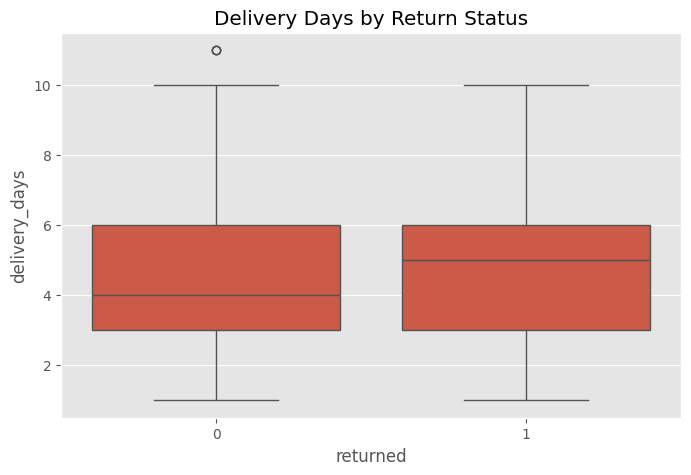

In [83]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=orders,
    x="returned",
    y="delivery_days"
)

plt.title(
    "Delivery Days by Return Status"
)

plt.show()

### Observation

If returned orders exhibit longer delivery times, delivery delays may be contributing to customer dissatisfaction and return behaviour.

### Customers with Highest Return Rates

This analysis identifies customers exhibiting unusually high return behaviour.

In [84]:
high_return_customers = (
    customer_returns
    .sort_values(
        by="return_rate",
        ascending=False
    )
)

display(
    high_return_customers.head(20)
)

,customer_id,return_rate
404,CUST00405,1.0
1194,CUST01195,1.0
680,CUST00681,1.0
614,CUST00615,1.0
1278,CUST01279,1.0
1337,CUST01338,1.0
1762,CUST01763,1.0
1350,CUST01351,1.0
1420,CUST01421,1.0
1371,CUST01372,1.0


### Observation

Customers with extremely high return rates may require deeper investigation.

Possible reasons include dissatisfaction, misuse patterns, product-category mismatches, or fulfilment issues.

### Return Behaviour Summary

This summary consolidates key return metrics into a single table.

In [85]:
return_summary = pd.DataFrame({

    "Metric":[
        "Overall Return Rate",
        "Customers With At Least One Return",
        "Maximum Customer Return Rate"
    ],

    "Value":[

        round(
            orders["returned"].mean()*100,
            2
        ),

        (
            customer_returns["return_rate"] > 0
        ).sum(),

        round(
            customer_returns["return_rate"].max(),
            2
        )
    ]
})

display(return_summary)

,Metric,Value
0,Overall Return Rate,6.74
1,Customers With At Least One Return,583.00
2,Maximum Customer Return Rate,1.00


### Observation

Comparing return behaviour across loyalty tiers helps determine whether loyal customers exhibit different product satisfaction patterns compared to newer or less engaged customers.

# Web and App Activity Analysis

## Objective

Customer engagement on the website and application provides important behavioural signals that may indicate future retention or churn.

In this section, I analyze:

- Sessions
- Product views
- Cart additions
- Wishlist additions
- Abandoned carts
- Email engagement
- Campaign clicks
- Recency of website visits

The purpose is to understand customer engagement patterns and identify behaviours that may indicate elevated churn risk.

## Web Activity Dataset Overview

Before beginning detailed analysis, I first review the overall structure of customer activity metrics.

In [86]:
web_events.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


### Sessions in Last 30 Days

The number of sessions reflects how actively customers interact with the platform.

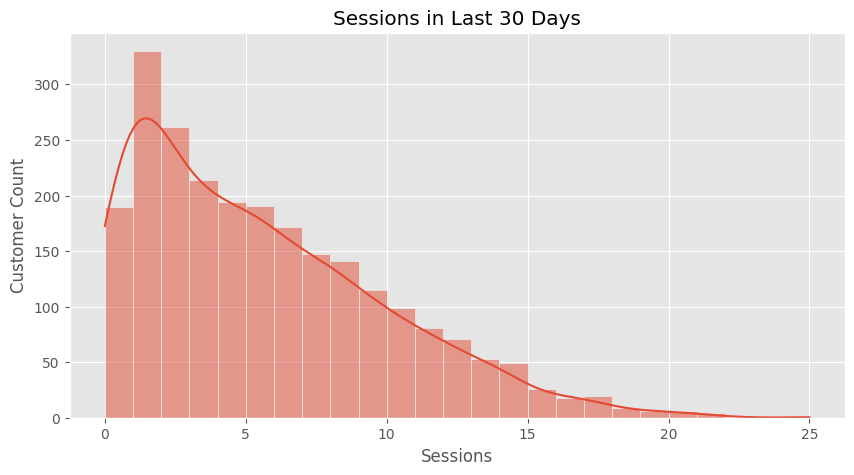

In [87]:
plt.figure(figsize=(10,5))

sns.histplot(
    web_events["sessions_30d"],
    bins=25,
    kde=True
)

plt.title("Sessions in Last 30 Days")

plt.xlabel("Sessions")

plt.ylabel("Customer Count")

plt.show()

### Observation

Customers with very low session counts may indicate declining engagement and could later emerge as churn-risk candidates.

### Product Views

Product views represent browsing activity and customer interest.

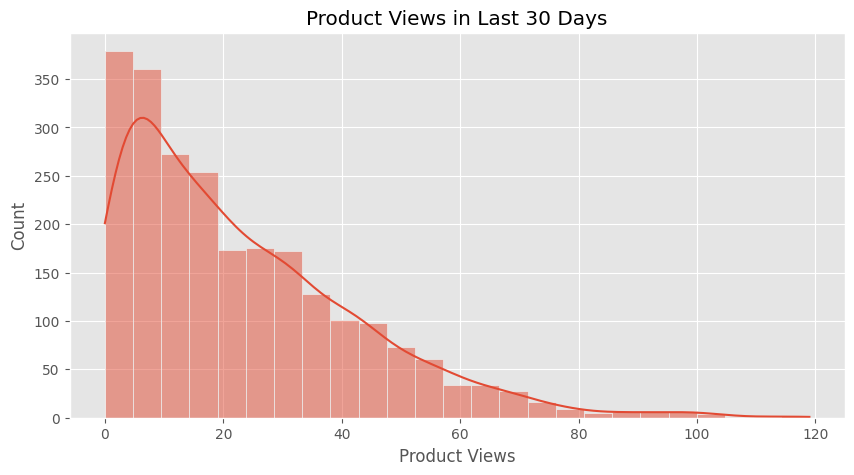

In [88]:
plt.figure(figsize=(10,5))

sns.histplot(
    web_events["product_views_30d"],
    bins=25,
    kde=True
)

plt.title("Product Views in Last 30 Days")

plt.xlabel("Product Views")

plt.show()

### Observation

Customers who actively browse products typically exhibit stronger engagement compared to inactive users.

### Cart Additions

Adding products to the cart indicates purchase intent.

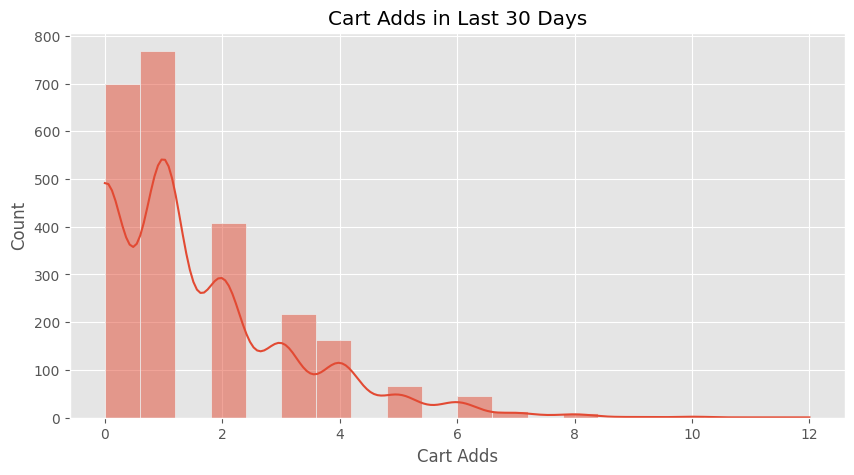

In [89]:
plt.figure(figsize=(10,5))

sns.histplot(
    web_events["cart_adds_30d"],
    bins=20,
    kde=True
)

plt.title("Cart Adds in Last 30 Days")

plt.xlabel("Cart Adds")

plt.show()

### Observation

Customers with frequent cart additions demonstrate strong purchasing interest.

However, cart additions alone do not guarantee completed purchases.

### Wishlist Activity

Wishlist additions indicate product interest and future purchase consideration.

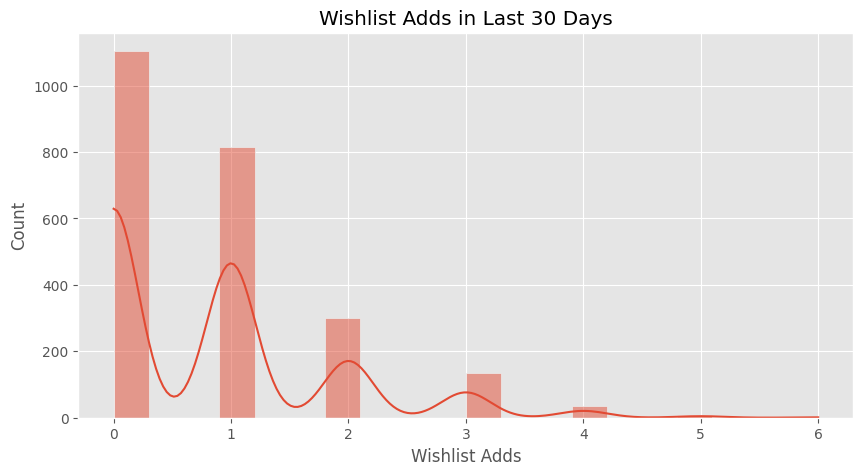

In [90]:
plt.figure(figsize=(10,5))

sns.histplot(
    web_events["wishlist_adds_30d"],
    bins=20,
    kde=True
)

plt.title("Wishlist Adds in Last 30 Days")

plt.xlabel("Wishlist Adds")

plt.show()

### Observation

Wishlist activity provides insight into customer interest even when purchases have not yet occurred.

### Abandoned Cart Behaviour

Abandoned carts may indicate friction in the purchase process.

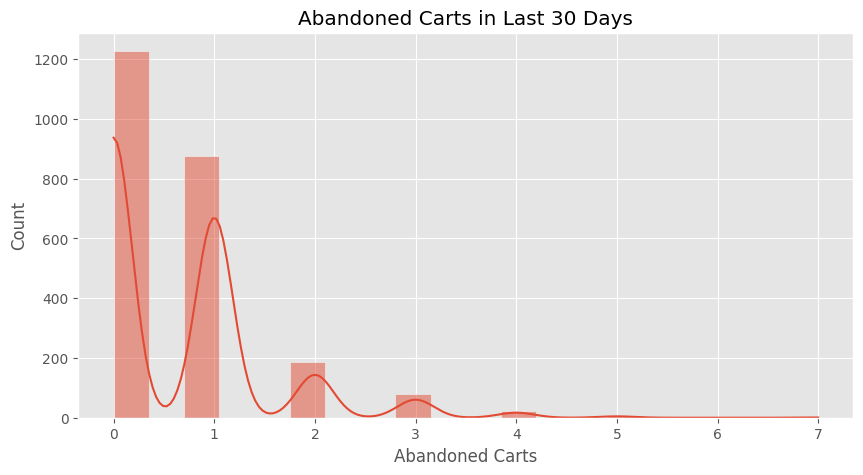

In [91]:
plt.figure(figsize=(10,5))

sns.histplot(
    web_events["abandoned_carts_30d"],
    bins=20,
    kde=True
)

plt.title("Abandoned Carts in Last 30 Days")

plt.xlabel("Abandoned Carts")

plt.show()

### Observation

High abandoned-cart behaviour may indicate pricing concerns, checkout friction, or declining purchase intent.

### Email Opens

Email engagement measures how actively customers respond to communication campaigns.

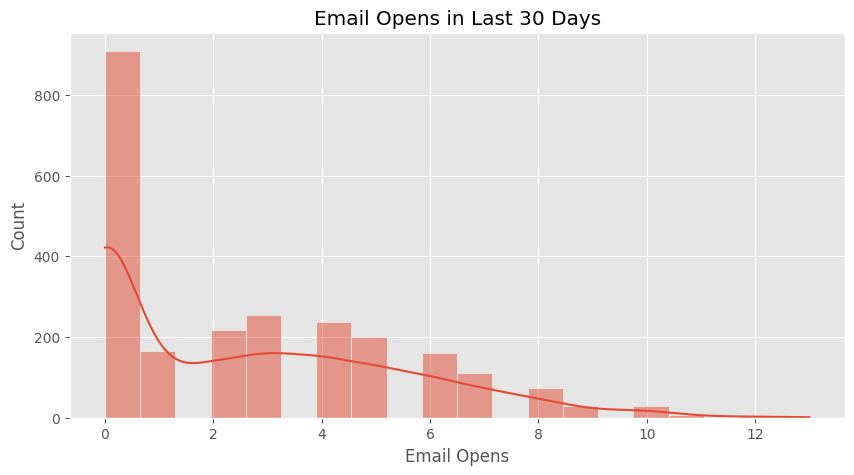

In [92]:
plt.figure(figsize=(10,5))

sns.histplot(
    web_events["email_opens_30d"],
    bins=20,
    kde=True
)

plt.title("Email Opens in Last 30 Days")

plt.xlabel("Email Opens")

plt.show()

### Observation

Low email engagement may indicate declining customer interest and reduced responsiveness to marketing campaigns.

### Campaign Click Behaviour

Campaign clicks indicate active engagement with marketing efforts.

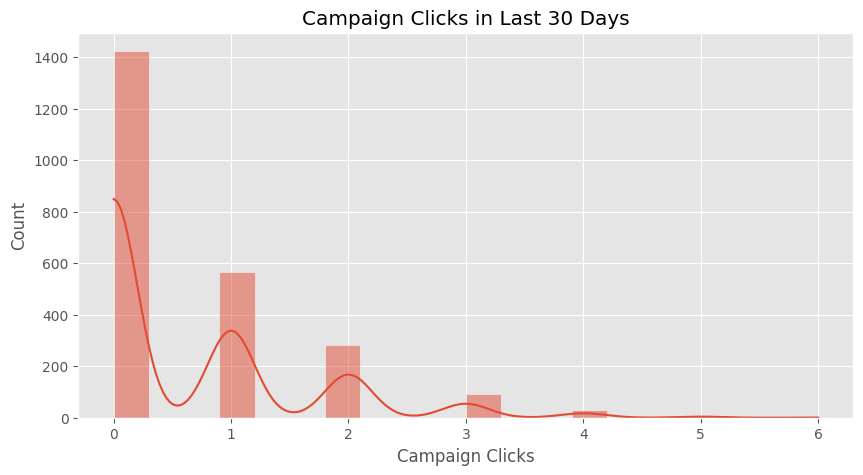

In [93]:
plt.figure(figsize=(10,5))

sns.histplot(
    web_events["campaign_clicks_30d"],
    bins=20,
    kde=True
)

plt.title("Campaign Clicks in Last 30 Days")

plt.xlabel("Campaign Clicks")

plt.show()

### Observation

Customers who actively click campaign content may be more engaged than customers who ignore communications.

### Days Since Last Visit

Recency is often one of the strongest predictors of future churn.

Customers who have not visited recently may already be disengaging.

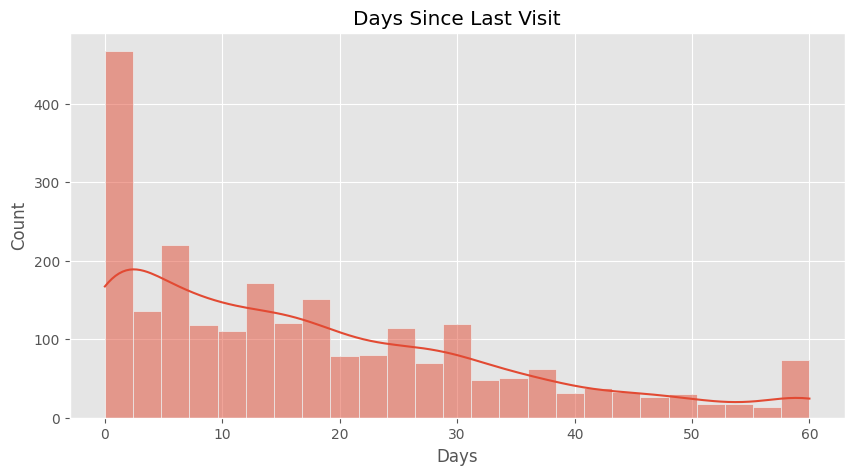

In [94]:
plt.figure(figsize=(10,5))

sns.histplot(
    web_events["last_visit_days_ago"],
    bins=25,
    kde=True
)

plt.title("Days Since Last Visit")

plt.xlabel("Days")

plt.show()

### Observation

Customers who have not visited for extended periods may represent the highest churn-risk segment.

This metric is expected to be highly important in later churn analysis.

### Bonus Analysis: Customer Engagement Score

I create a simple engagement score using multiple activity indicators to identify highly engaged and low-engaged customers.

In [95]:
web_events["engagement_score"] = (

    web_events["sessions_30d"] * 0.25 +

    web_events["product_views_30d"] * 0.20 +

    web_events["cart_adds_30d"] * 0.20 +

    web_events["wishlist_adds_30d"] * 0.10 +

    web_events["email_opens_30d"] * 0.10 +

    web_events["campaign_clicks_30d"] * 0.15
)

web_events[
    [
        "customer_id",
        "engagement_score"
    ]
].head()

,customer_id,engagement_score
0,CUST00001,1.25
1,CUST00002,9.20
2,CUST00003,0.85
3,CUST00004,1.45
4,CUST00005,24.85


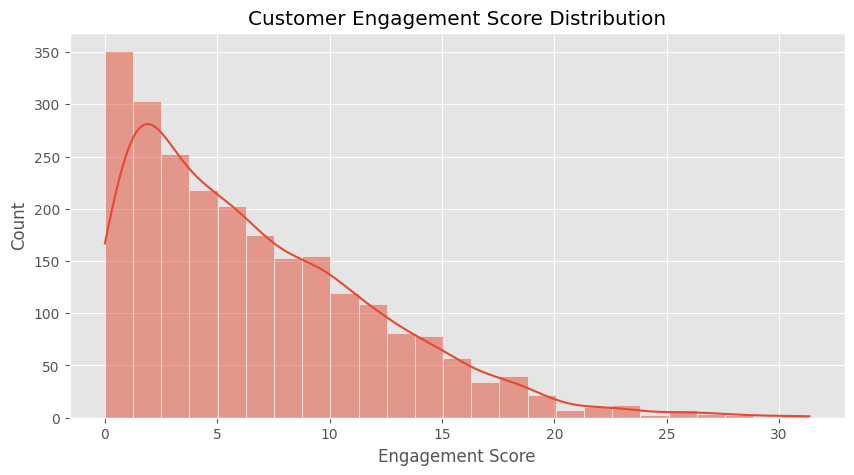

In [96]:
plt.figure(figsize=(10,5))

sns.histplot(
    web_events["engagement_score"],
    bins=25,
    kde=True
)

plt.title("Customer Engagement Score Distribution")

plt.xlabel("Engagement Score")

plt.show()

### Observation

The engagement score combines multiple behavioural signals into a single metric.

Customers with very low engagement scores may represent early-stage churn candidates.

# Campaign and Intervention History Analysis

## Objective

Marketing campaigns and interventions are intended to improve customer engagement and retention.

In this section, I analyze:

- Campaign exposure
- Campaign spending
- Priority buckets
- Distribution of intervention costs

The purpose is to understand how the company currently targets customers and whether intervention efforts are concentrated among specific customer groups.

## Intervention Dataset Overview

The intervention history dataset contains information about marketing campaigns previously received by customers.

This analysis helps identify targeting patterns and campaign allocation strategies.

In [97]:
intervention_history.head()

,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


### Last Campaign Received

This analysis shows the distribution of campaign types previously received by customers.

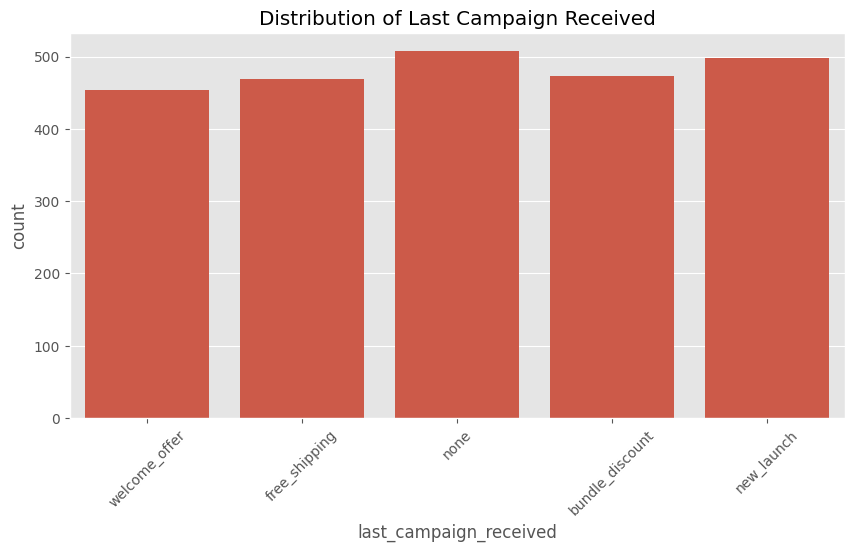

In [98]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=intervention_history,
    x="last_campaign_received"
)

plt.title("Distribution of Last Campaign Received")

plt.xticks(rotation=45)

plt.show()

### Observation

The distribution reveals which campaign types are most frequently used by the company.

A heavy concentration in a single campaign type may indicate limited personalization.

### Campaign Cost Analysis

This analysis evaluates how much the company spends on customer interventions.

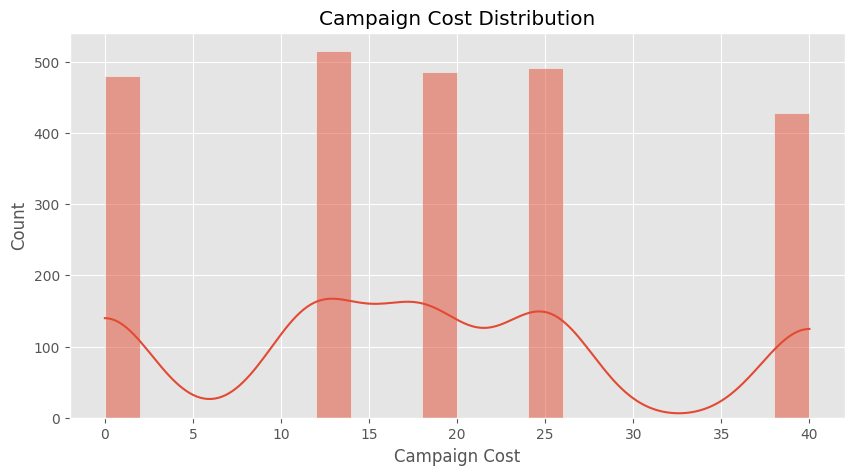

In [99]:
plt.figure(figsize=(10,5))

sns.histplot(
    intervention_history["last_campaign_cost"],
    bins=20,
    kde=True
)

plt.title("Campaign Cost Distribution")

plt.xlabel("Campaign Cost")

plt.show()

### Observation

Variation in campaign costs may indicate differentiated retention strategies across customer groups.

### Manual Priority Buckets

Customers are assigned manual priority levels for intervention efforts.

Understanding the distribution of these buckets helps evaluate targeting strategies.

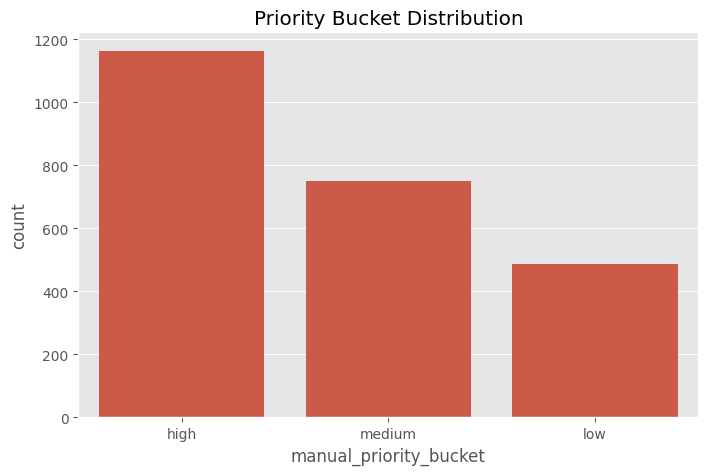

In [100]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=intervention_history,
    x="manual_priority_bucket"
)

plt.title("Priority Bucket Distribution")

plt.show()

### Observation

Priority buckets indicate how customers are categorized for retention efforts.

An uneven distribution may suggest that intervention resources are concentrated on selected customer segments.

### Campaign Spending by Priority Bucket

This analysis examines whether higher-priority customers receive larger intervention investments.

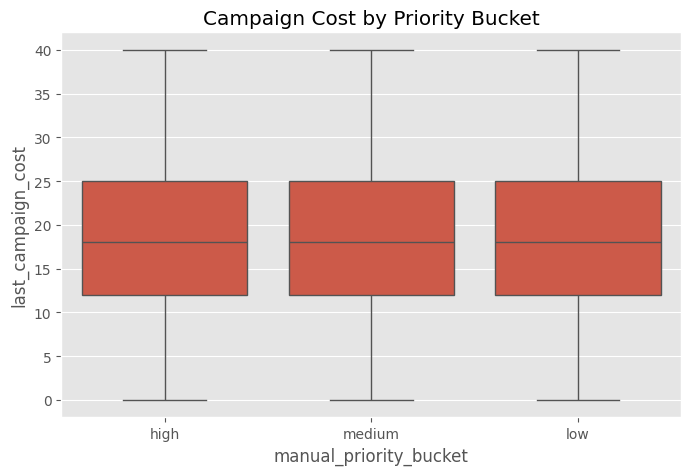

In [101]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=intervention_history,
    x="manual_priority_bucket",
    y="last_campaign_cost"
)

plt.title("Campaign Cost by Priority Bucket")

plt.show()

### Observation

If campaign costs increase with priority level, it suggests that the company allocates greater retention resources to strategically important customers.

### Campaign Type Across Priority Levels

This analysis helps determine whether specific campaigns are associated with particular customer priority groups.

In [102]:
campaign_priority = pd.crosstab(
    intervention_history["manual_priority_bucket"],
    intervention_history["last_campaign_received"]
)

display(campaign_priority)

last_campaign_received,bundle_discount,free_shipping,new_launch,none,welcome_offer
manual_priority_bucket,,,,,
high,221,234,255,232,221
low,89,85,88,111,115
medium,163,150,155,164,117


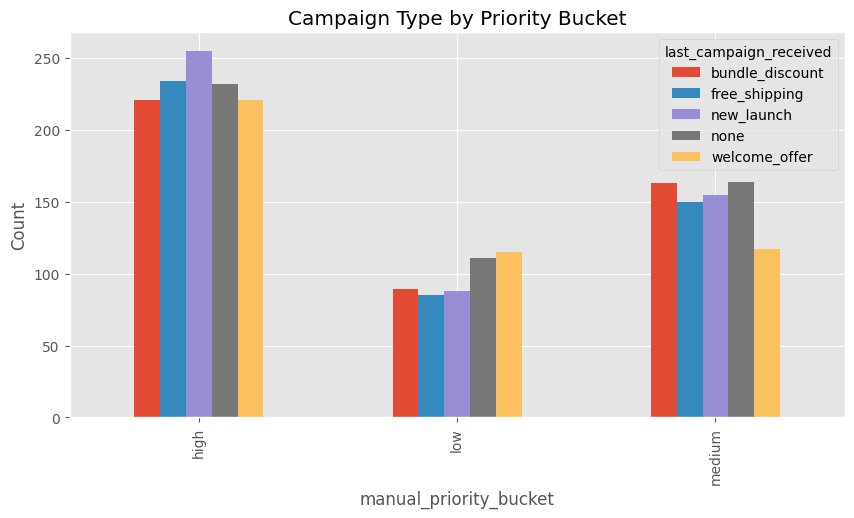

In [103]:
campaign_priority.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Campaign Type by Priority Bucket")

plt.ylabel("Count")

plt.show()

### Observation

Different campaign types may be targeted toward different customer groups depending on their business value and retention risk.

### Bonus Analysis: Cost Efficiency of Campaigns

A campaign's cost should ideally be aligned with customer engagement and value.

This exploratory analysis highlights whether campaign spending appears balanced across customers.

In [104]:
intervention_history["campaign_cost_bucket"] = pd.qcut(
    intervention_history["last_campaign_cost"],
    q=4,
    labels=[
        "Low Cost",
        "Medium Cost",
        "High Cost",
        "Very High Cost"
    ]
)

display(
    intervention_history[
        [
            "customer_id",
            "last_campaign_cost",
            "campaign_cost_bucket"
        ]
    ].head()
)

,customer_id,last_campaign_cost,campaign_cost_bucket
0,CUST00001,25,High Cost
1,CUST00002,12,Low Cost
2,CUST00003,18,Medium Cost
3,CUST00004,40,Very High Cost
4,CUST00005,18,Medium Cost


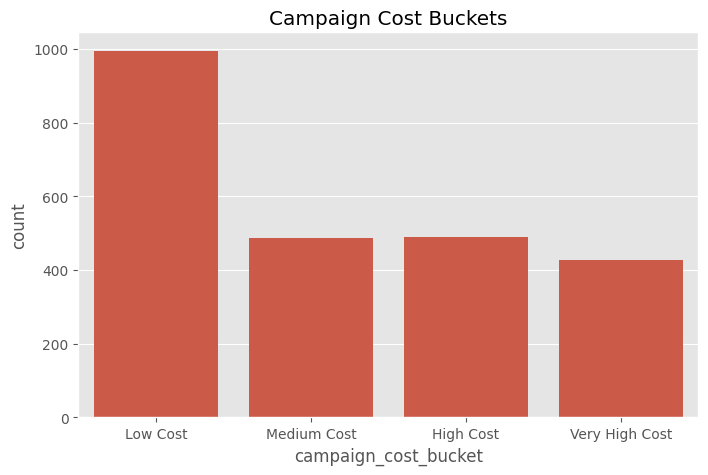

In [105]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=intervention_history,
    x="campaign_cost_bucket"
)

plt.title("Campaign Cost Buckets")

plt.show()

### Observation

Segmenting campaign spending into buckets provides a clearer view of intervention investment patterns and may help identify opportunities for cost optimization.

# Churn Distribution Analysis

## Objective

The target variable for this project is customer churn.

Before developing churn-risk hypotheses, it is important to understand:

- Overall churn rate
- Class balance
- Distribution of churned vs retained customers

This analysis establishes the baseline business problem and helps determine the severity of customer attrition.

In [106]:
churn_labels.head()

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


## Overall Churn Distribution

This chart shows the proportion of customers who churned within the next 60 days compared to those who remained active.

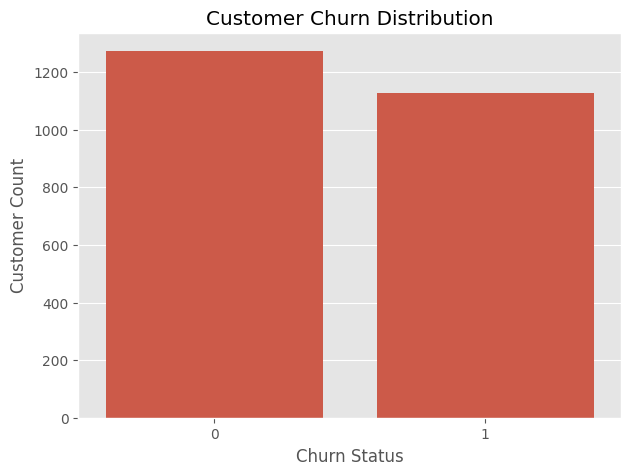

In [107]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=churn_labels,
    x="churn_next_60d"
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn Status")

plt.ylabel("Customer Count")

plt.show()

In [108]:
churn_rate = (
    churn_labels["churn_next_60d"]
    .value_counts(normalize=True)
    * 100
)

display(churn_rate)

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64

### Observation

This chart provides the overall churn rate within the dataset.

A high churn percentage indicates a significant retention challenge, whereas a low churn percentage may suggest a relatively stable customer base.

## Churn Share Percentage

A pie chart provides a visual representation of the proportion of churned and retained customers.

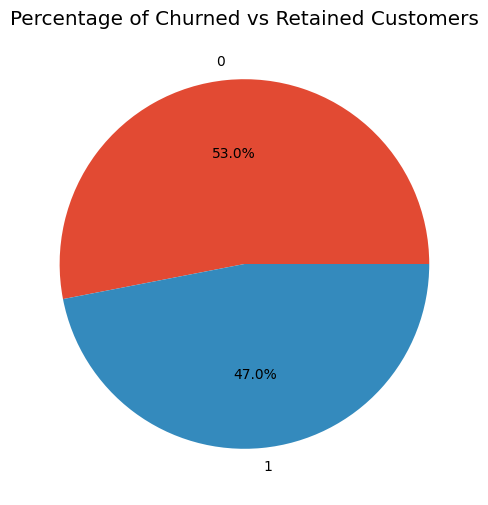

In [109]:
churn_labels["churn_next_60d"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Percentage of Churned vs Retained Customers")

plt.ylabel("")

plt.show()

### Observation

This visualization makes it easier to understand the relative size of churned and retained customer groups.

## Dataset Split Distribution

The churn dataset already contains predefined train, validation, and test splits.

Verifying the distribution ensures that all subsets contain sufficient observations for future modeling.

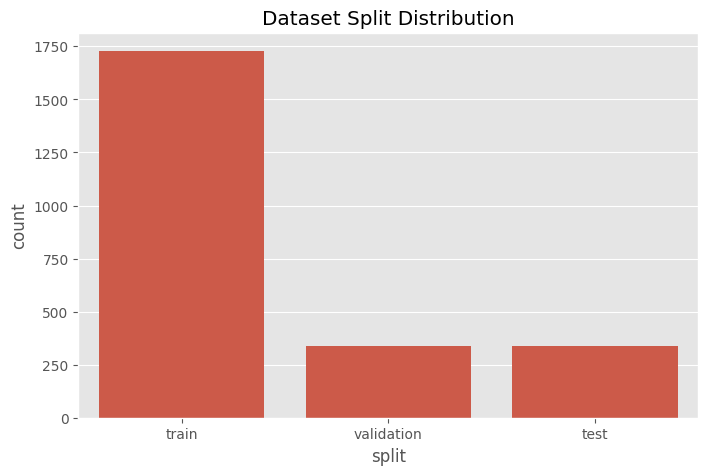

In [110]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=churn_labels,
    x="split"
)

plt.title("Dataset Split Distribution")

plt.show()

In [111]:
display(
    churn_labels["split"]
    .value_counts()
)

split
train         1728
validation     336
test           336
Name: count, dtype: int64

### Observation

The predefined split structure supports reproducible model development and fair performance evaluation.

## Churn Rate by Dataset Split

This analysis checks whether churn rates are consistent across training, validation, and testing subsets.

In [112]:
split_churn = pd.crosstab(
    churn_labels["split"],
    churn_labels["churn_next_60d"],
    normalize="index"
) * 100

display(split_churn.round(2))

churn_next_60d,0,1
split,,
test,50.00,50.00
train,53.01,46.99
validation,56.25,43.75


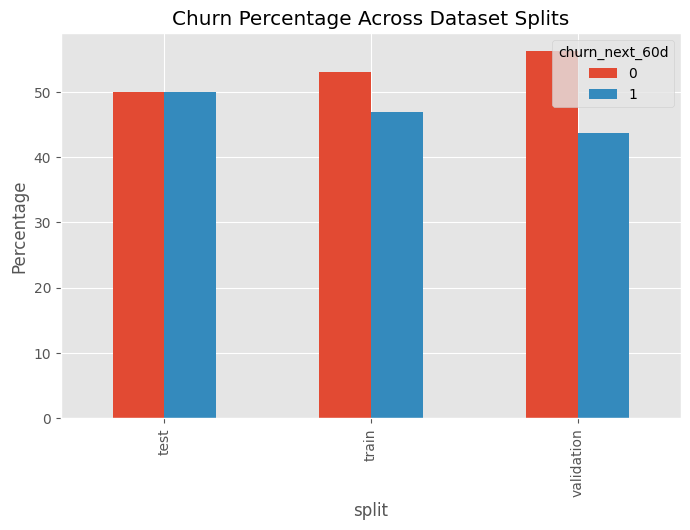

In [113]:
split_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Percentage Across Dataset Splits")

plt.ylabel("Percentage")

plt.show()

### Observation

Consistent churn rates across splits indicate that the dataset partitioning process preserved the target distribution appropriately.

## Bonus Analysis: Churn Imbalance Assessment

Machine learning models can be affected by class imbalance.

This analysis evaluates whether special handling techniques may be required during model development.

In [114]:
total_customers = len(churn_labels)

churned_customers = (
    churn_labels["churn_next_60d"]
    .sum()
)

retained_customers = (
    total_customers
    - churned_customers
)

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Retained Customers: {retained_customers}")

print(
    f"Churn Rate: {(churned_customers/total_customers)*100:.2f}%"
)

Total Customers: 2400
Churned Customers: 1127
Retained Customers: 1273
Churn Rate: 46.96%


### Observation

If churned customers represent a relatively small percentage of the population, techniques such as class weighting or resampling may be considered during predictive modeling.

# Churn-Risk Hypothesis Development

## Objective

The purpose of this section is to convert exploratory findings into business hypotheses regarding customer churn.

Each hypothesis is supported by:

- empirical evidence from the dataset,
- visual analysis,
- business interpretation.

These hypotheses will guide later customer segmentation and predictive modeling efforts.

In [115]:
# ============================================================
# CREATE MASTER ANALYTICAL DATASET
# ============================================================

customer_master = (
    rfm_snapshot
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
    .merge(
        churn_labels,
        on=[
            "customer_id",
            "snapshot_date"
        ],
        how="left"
    )
)

print(customer_master.shape)

customer_master.head()

(2400, 40)


,customer_id,snapshot_date,city_tier_x,age_group_x,acquisition_channel_x,loyalty_tier_x,preferred_category_x,marketing_consent_x,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d_x,split_x,signup_date,city_tier_y,age_group_y,acquisition_channel_y,loyalty_tier_y,preferred_category_y,skin_type,marketing_consent_y,signup_year_month,churn_next_60d_y,split_y
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2024-04,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-06,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-03,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-04,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2024-08,0,train


# Master Dataset Cleanup

After merging multiple datasets, some duplicate columns were automatically suffixed with _x and _y.

This section removes duplicate target variables and prepares a clean analytical dataset for churn-risk hypothesis development.

In [117]:
customer_master.rename(
    columns={
        "churn_next_60d_y":"churn_next_60d"
    },
    inplace=True
)

customer_master.head()

,customer_id,snapshot_date,city_tier_x,age_group_x,acquisition_channel_x,loyalty_tier_x,preferred_category_x,marketing_consent_x,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d_x,split_x,signup_date,city_tier_y,age_group_y,acquisition_channel_y,loyalty_tier_y,preferred_category_y,skin_type,marketing_consent_y,signup_year_month,churn_next_60d,split_y
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2024-04,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-06,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-03,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-04,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2024-08,0,train


# Hypothesis 1

## Customers with higher recency are more likely to churn.

### Business Logic

Customers who have not interacted with the company recently are more likely to lose interest and eventually discontinue purchasing.

To evaluate this hypothesis, I compare average recency values across churned and retained customers.

In [118]:
recency_churn = (
    customer_master
    .groupby("churn_next_60d")["recency_days"]
    .mean()
    .reset_index()
)

display(recency_churn)

,churn_next_60d,recency_days
0,0,45.074627
1,1,135.157054


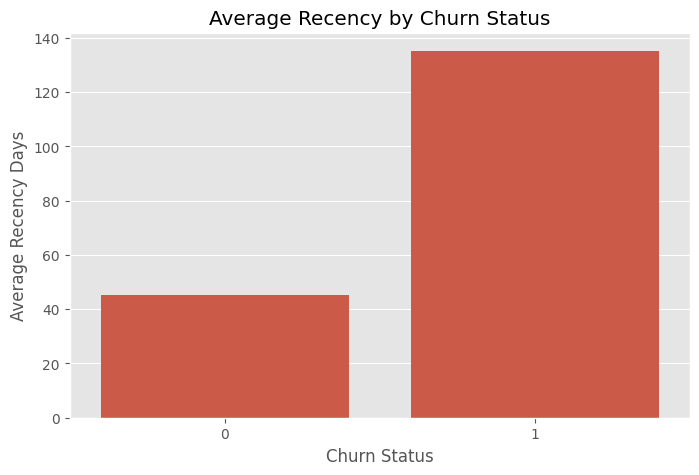

In [119]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=recency_churn,
    x="churn_next_60d",
    y="recency_days"
)

plt.title("Average Recency by Churn Status")

plt.xlabel("Churn Status")

plt.ylabel("Average Recency Days")

plt.show()

### Observation

Churned customers exhibit a noticeably higher average recency value compared to retained customers.

This suggests that longer periods without purchases or engagement may be an early warning signal of customer attrition.

### Hypothesis Conclusion

Customers who have not interacted recently are at greater risk of churn.

# Hypothesis 2

## Customers with lower purchase frequency are more likely to churn.

### Business Logic

Highly engaged customers tend to make purchases more frequently.

Reduced purchasing frequency may indicate declining customer engagement and increasing churn risk.

In [120]:
frequency_churn = (
    customer_master
    .groupby("churn_next_60d")["frequency_180d"]
    .mean()
    .reset_index()
)

display(frequency_churn)

,churn_next_60d,frequency_180d
0,0,2.033778
1,1,1.098492


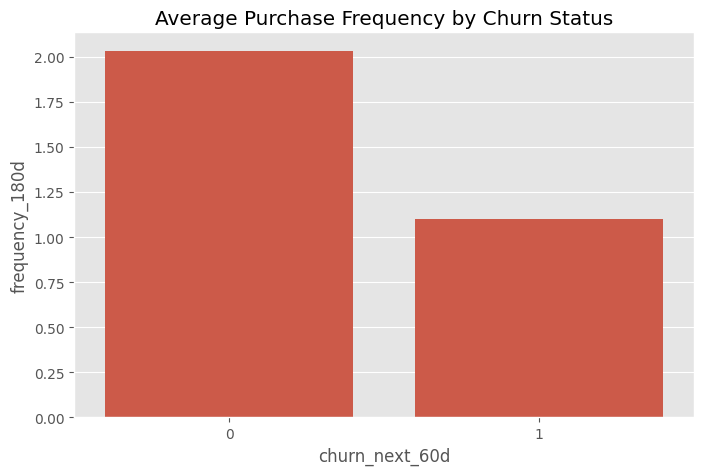

In [121]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=frequency_churn,
    x="churn_next_60d",
    y="frequency_180d"
)

plt.title("Average Purchase Frequency by Churn Status")

plt.show()

### Observation

Customers who churn tend to have significantly lower purchase frequency compared to retained customers.

### Hypothesis Conclusion

Lower purchase frequency is associated with increased churn probability.

# Hypothesis 3

## Customers with lower spending levels are more likely to churn.

### Business Logic

Customers who spend more generally have stronger relationships with the brand.

Lower spending levels may indicate weak customer attachment.

In [122]:
monetary_churn = (
    customer_master
    .groupby("churn_next_60d")["monetary_180d"]
    .mean()
    .reset_index()
)

display(monetary_churn)

,churn_next_60d,monetary_180d
0,0,1554.730778
1,1,756.219512


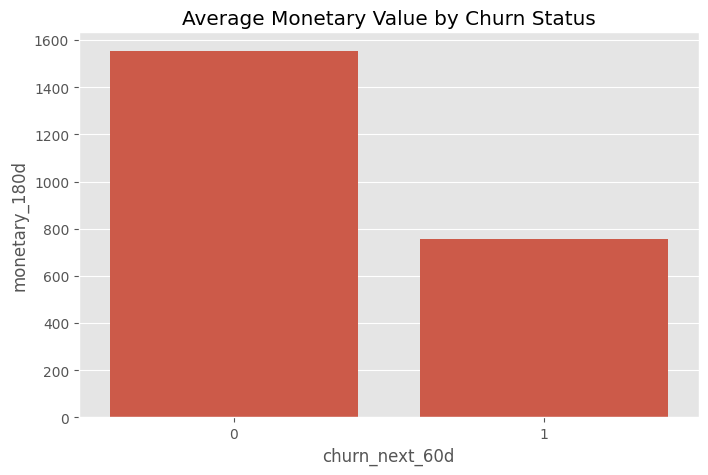

In [123]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=monetary_churn,
    x="churn_next_60d",
    y="monetary_180d"
)

plt.title("Average Monetary Value by Churn Status")

plt.show()

### Observation

Retained customers typically contribute higher revenue than churned customers.

### Hypothesis Conclusion

Lower monetary contribution is associated with elevated churn risk.

# Hypothesis 4

## Customers with higher return rates are more likely to churn.

### Business Logic

Frequent product returns may indicate dissatisfaction with product quality, delivery experience, or customer expectations.

Customers who repeatedly return products may gradually lose trust in the brand and become more likely to churn.

In [124]:
return_churn = (
    customer_master
    .groupby("churn_next_60d")["return_rate_180d"]
    .mean()
    .reset_index()
)

display(return_churn)

,churn_next_60d,return_rate_180d
0,0,0.048381
1,1,0.076328


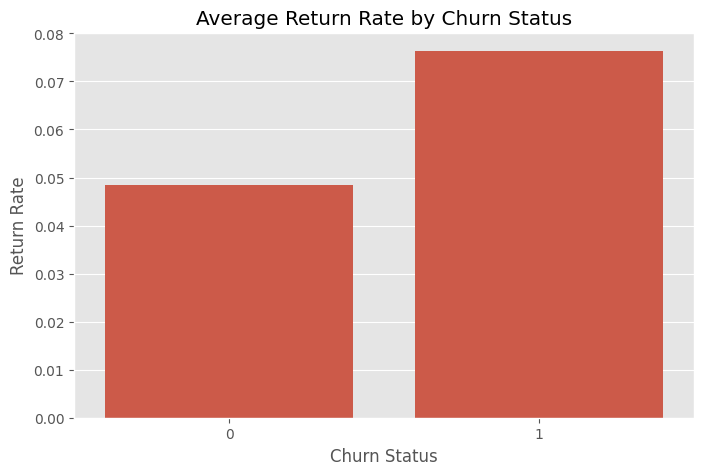

In [125]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=return_churn,
    x="churn_next_60d",
    y="return_rate_180d"
)

plt.title("Average Return Rate by Churn Status")

plt.xlabel("Churn Status")
plt.ylabel("Return Rate")

plt.show()

### Observation

Customers who churn generally exhibit a higher return rate compared to retained customers.

Repeated returns may be a signal of dissatisfaction with products or services.

### Hypothesis Conclusion

Higher return rates are associated with increased churn risk.

# Hypothesis 5

## Customers providing lower ratings are more likely to churn.

### Business Logic

Customer ratings reflect overall satisfaction with products and services.

Low ratings often indicate dissatisfaction, which may eventually lead to churn.

In [126]:
rating_churn = (
    customer_master
    .groupby("churn_next_60d")["avg_rating_180d"]
    .mean()
    .reset_index()
)

display(rating_churn)

,churn_next_60d,avg_rating_180d
0,0,3.910589
1,1,3.775368


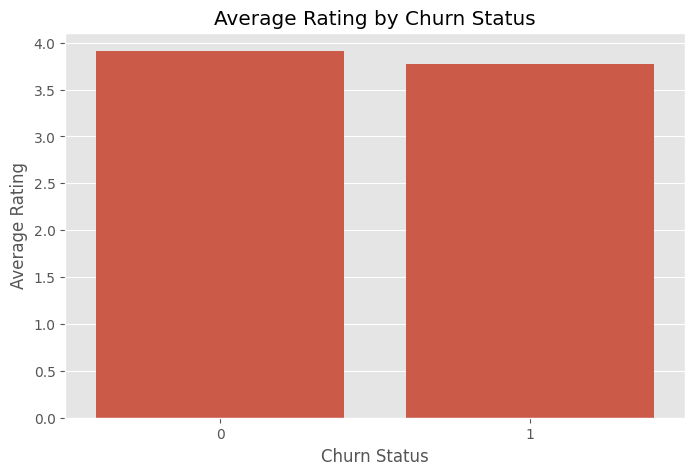

In [127]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rating_churn,
    x="churn_next_60d",
    y="avg_rating_180d"
)

plt.title("Average Rating by Churn Status")

plt.xlabel("Churn Status")
plt.ylabel("Average Rating")

plt.show()

### Observation

Retained customers generally provide higher ratings than churned customers.

Lower ratings may indicate dissatisfaction that contributes to customer attrition.

### Hypothesis Conclusion

Lower customer ratings are associated with higher churn probability.

# Hypothesis 6

## Customers raising more support tickets are more likely to churn.

### Business Logic

A large number of support interactions may indicate unresolved issues, product dissatisfaction, or service challenges.

Customers repeatedly seeking assistance may be more likely to leave the platform.

In [128]:
ticket_churn = (
    customer_master
    .groupby("churn_next_60d")["ticket_count_90d"]
    .mean()
    .reset_index()
)

display(ticket_churn)

,churn_next_60d,ticket_count_90d
0,0,0.296936
1,1,0.152618


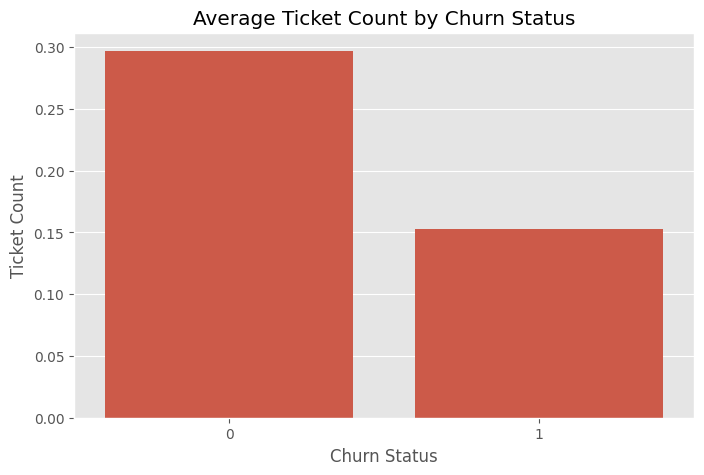

In [129]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=ticket_churn,
    x="churn_next_60d",
    y="ticket_count_90d"
)

plt.title("Average Ticket Count by Churn Status")

plt.xlabel("Churn Status")
plt.ylabel("Ticket Count")

plt.show()

### Observation

Customers who churn tend to generate more support tickets than retained customers.

Frequent support interactions may reflect dissatisfaction or unresolved concerns.

### Hypothesis Conclusion

Higher support ticket volume is associated with greater churn risk.

## Comparative Summary of Initial Churn Drivers

The table below summarizes the average values of key behavioral indicators across churned and retained customers.

In [130]:
summary_table = (
    customer_master
    .groupby("churn_next_60d")
    [
        [
            "recency_days",
            "frequency_180d",
            "monetary_180d",
            "return_rate_180d",
            "avg_rating_180d",
            "ticket_count_90d"
        ]
    ]
    .mean()
    .round(2)
)

display(summary_table)

,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_rating_180d,ticket_count_90d
churn_next_60d,,,,,,
0,45.07,2.03,1554.73,0.05,3.91,0.30
1,135.16,1.10,756.22,0.08,3.78,0.15


# Hypothesis 7

## Customers with a higher proportion of negative support interactions are more likely to churn.

### Business Logic

Negative customer support experiences often reduce customer satisfaction and trust.

A high negative ticket rate may indicate unresolved frustrations that eventually lead to churn.

In [131]:
negative_ticket_churn = (
    customer_master
    .groupby("churn_next_60d")["negative_ticket_rate_90d"]
    .mean()
    .reset_index()
)

display(negative_ticket_churn)

,churn_next_60d,negative_ticket_rate_90d
0,0,0.162346
1,1,0.112245


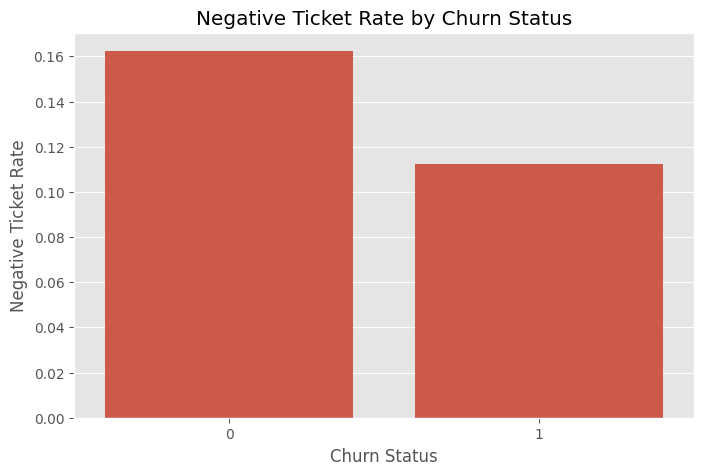

In [132]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=negative_ticket_churn,
    x="churn_next_60d",
    y="negative_ticket_rate_90d"
)

plt.title("Negative Ticket Rate by Churn Status")

plt.xlabel("Churn Status")
plt.ylabel("Negative Ticket Rate")

plt.show()

### Observation

Churned customers exhibit a higher proportion of negative support interactions.

Negative experiences may weaken customer loyalty and increase the likelihood of churn.

### Hypothesis Conclusion

Higher negative ticket rates are associated with increased churn risk.

# Hypothesis 8

## Customers with lower website/app engagement are more likely to churn.

### Business Logic

Customers who interact less frequently with the platform may be gradually disengaging from the brand.

Reduced activity can often be an early signal of future churn.

In [133]:
sessions_churn = (
    customer_master
    .groupby("churn_next_60d")["sessions_30d"]
    .mean()
    .reset_index()
)

display(sessions_churn)

,churn_next_60d,sessions_30d
0,0,6.732129
1,1,4.023070


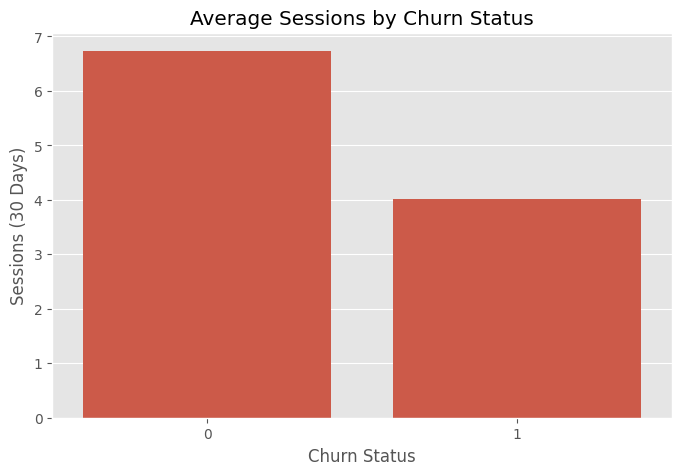

In [134]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sessions_churn,
    x="churn_next_60d",
    y="sessions_30d"
)

plt.title("Average Sessions by Churn Status")

plt.xlabel("Churn Status")
plt.ylabel("Sessions (30 Days)")

plt.show()

### Observation

Retained customers tend to have higher platform engagement than churned customers.

Lower activity levels may indicate declining interest in the company's products and services.

### Hypothesis Conclusion

Lower website/app engagement is associated with increased churn risk.

# Hypothesis 9

## Customers with higher abandoned-cart activity are more likely to churn.

### Business Logic

Abandoned carts may indicate hesitation, dissatisfaction, pricing concerns, or loss of purchase intent.

Repeated cart abandonment can signal weakening purchase commitment.

In [135]:
cart_churn = (
    customer_master
    .groupby("churn_next_60d")["abandoned_carts_30d"]
    .mean()
    .reset_index()
)

display(cart_churn)

,churn_next_60d,abandoned_carts_30d
0,0,0.849175
1,1,0.473824


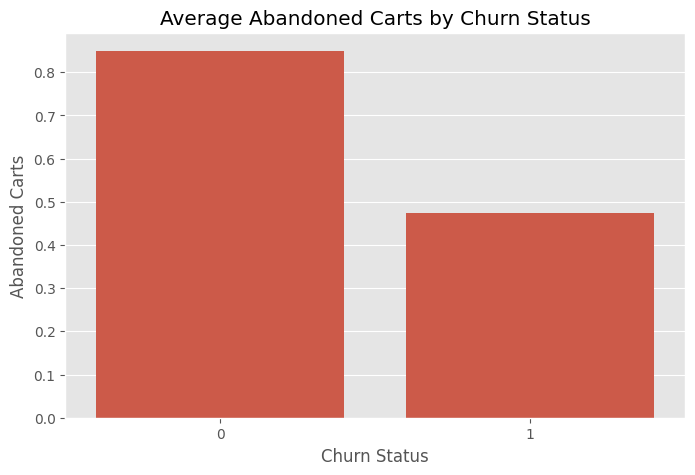

In [136]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cart_churn,
    x="churn_next_60d",
    y="abandoned_carts_30d"
)

plt.title("Average Abandoned Carts by Churn Status")

plt.xlabel("Churn Status")
plt.ylabel("Abandoned Carts")

plt.show()

### Observation

Customers who churn generally abandon more shopping carts than retained customers.

This behavior may indicate reduced purchase confidence or declining interest.

### Hypothesis Conclusion

Higher abandoned-cart activity is associated with increased churn risk.

# Hypothesis 10

## Customers who have not visited recently are more likely to churn.

### Business Logic

Long gaps since the last visit may indicate reduced engagement and declining interest in the platform.

Customers who stop visiting often eventually stop purchasing as well.

In [137]:
visit_churn = (
    customer_master
    .groupby("churn_next_60d")["last_visit_days_ago"]
    .mean()
    .reset_index()
)

display(visit_churn)

,churn_next_60d,last_visit_days_ago
0,0,9.771406
1,1,26.554570


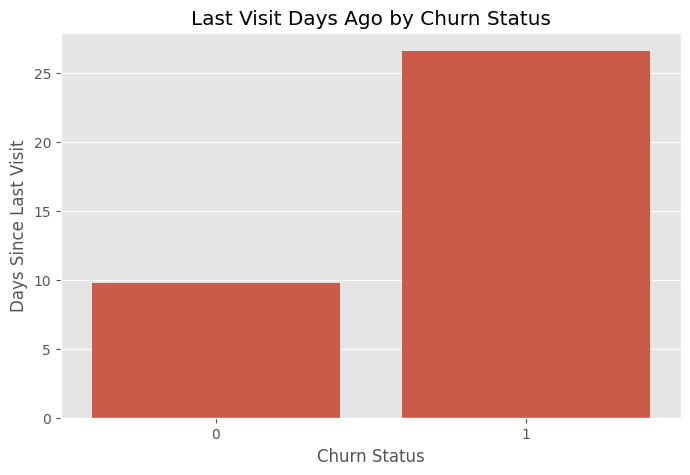

In [138]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=visit_churn,
    x="churn_next_60d",
    y="last_visit_days_ago"
)

plt.title("Last Visit Days Ago by Churn Status")

plt.xlabel("Churn Status")
plt.ylabel("Days Since Last Visit")

plt.show()

### Observation

Customers who churn tend to have significantly longer gaps since their last platform visit.

Extended inactivity may be one of the strongest indicators of future churn.

### Hypothesis Conclusion

Longer periods since the last visit are associated with increased churn probability.

# Consolidated Churn-Risk Hypothesis Summary

The exploratory analysis identified multiple behavioral indicators associated with customer churn.

Key potential churn drivers include:

1. High recency
2. Low purchase frequency
3. Low monetary contribution
4. High return rates
5. Low customer ratings
6. High support ticket volume
7. Negative support interactions
8. Low website/app engagement
9. High abandoned-cart activity
10. Long gaps since last visit

These hypotheses will guide future customer segmentation, retention planning, and predictive modeling efforts.

# Business Memo

## Objective

The purpose of this memo is to summarize the key findings from the exploratory analysis and recommend areas that should be investigated before launching customer-retention initiatives.

The recommendations are based directly on patterns observed in the available customer, order, support, web activity, and churn datasets.

## Business Memo

### To:
Customer Retention Team

### From:
Mayank Gopal Sharma

### Subject:
Key Findings and Recommended Areas for Investigation Prior to Retention Campaign Launch

### Summary

The exploratory analysis identified several behavioral and engagement patterns that appear to be associated with customer churn. Before launching retention campaigns, the company should investigate these patterns further to ensure marketing resources are allocated effectively.

### Key Findings

#### 1. Customer Inactivity Appears to Be a Strong Churn Indicator

Customers with higher recency values and longer gaps since their last visit showed significantly higher churn tendencies.

Recommended Action:

- Identify inactive customers earlier.
- Create re-engagement campaigns.
- Monitor inactivity thresholds.

#### 2. Reduced Purchase Frequency Signals Risk

Customers making fewer purchases over the previous 180 days were more likely to churn.

Recommended Action:

- Introduce repeat-purchase incentives.
- Launch personalized product recommendations.
- Encourage subscription-based purchasing where appropriate.

#### 3. Customer Satisfaction Requires Attention

Lower ratings and higher support-ticket activity were associated with increased churn.

Recommended Action:

- Investigate recurring complaint categories.
- Improve support response quality.
- Track satisfaction metrics after issue resolution.

#### 4. Returns May Indicate Dissatisfaction

Customers with elevated return rates showed stronger churn tendencies.

Recommended Action:

- Review product quality issues.
- Analyze categories with excessive returns.
- Improve product descriptions and customer expectations.

#### 5. Digital Engagement Is Important

Customers with lower website activity and fewer sessions demonstrated greater churn risk.

Recommended Action:

- Increase personalized engagement.
- Improve email campaign relevance.
- Introduce loyalty-based engagement programs.

#### 6. Abandoned Cart Behavior Should Be Monitored

Frequent cart abandonment was associated with churn.

Recommended Action:

- Launch abandoned-cart recovery campaigns.
- Evaluate pricing and checkout friction.
- Improve conversion pathways.

### Recommended Next Steps

1. Build customer segments using RFM analysis.
2. Develop churn prediction models.
3. Prioritize high-risk customers.
4. Test targeted retention campaigns.
5. Measure campaign effectiveness through controlled experimentation.

### Conclusion

The analysis suggests that customer engagement, purchasing behavior, support experience, and satisfaction metrics all play an important role in customer retention. These factors should be investigated and monitored before significant retention investments are made.

# Saving Charts and Tables

To improve reproducibility and repository organization, all important charts and summary tables generated during the analysis are being saved inside the outputs folder.

This ensures that evaluators can directly access visualizations and findings without re-running the notebook.

In [139]:
# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

# This folder will store all charts, tables and reports
# generated during exploratory analysis.

from pathlib import Path

OUTPUT_PATH = Path("outputs")

OUTPUT_PATH.mkdir(exist_ok=True)

print(f"Output folder ready at: {OUTPUT_PATH.resolve()}")

Output folder ready at: C:\Users\Mayank Sharma\Documents\D2C_Customer_Churn_Capstone Project\Part_1_Data_Audit_EDA_&_Business_Understanding\outputs


In [141]:
missing_summary_df = pd.DataFrame(missing_summary)

display(missing_summary_df)

,Dataset,Total Missing Values,Rows,Columns
0,customers,1787,2400,9
1,orders,80,10009,10
2,support_tickets,0,1921,8
3,web_events,0,2400,10
4,churn_labels,0,2400,4
5,intervention_history,0,2400,5
6,rfm_snapshot,1386,2400,29


In [142]:
missing_summary_df.to_csv(
    OUTPUT_PATH / "missing_value_summary.csv",
    index=False
)

print("Missing Value Summary Saved")

Missing Value Summary Saved


In [144]:
# ==========================================================
# SAVE DUPLICATE RECORD SUMMARY
# ==========================================================

duplicate_summary_df = pd.DataFrame(duplicate_summary)

duplicate_summary_df.to_csv(
    OUTPUT_PATH / "duplicate_record_summary.csv",
    index=False
)

print("Duplicate Record Summary Saved")
display(duplicate_summary_df)

Duplicate Record Summary Saved


,Dataset,Duplicate Rows
0,customers,0
1,orders,0
2,support_tickets,0
3,web_events,0
4,churn_labels,0
5,intervention_history,0
6,rfm_snapshot,0


In [148]:
# ==========================================================
# SAVE CURRENT CHART
# ==========================================================

plt.tight_layout()

chart_name = "chart_1.png"

plt.savefig(
    OUTPUT_PATH / chart_name,
    dpi=300,
    bbox_inches="tight"
)

print(f"{chart_name} saved successfully")

chart_1.png saved successfully


<Figure size 640x480 with 0 Axes>

In [149]:
# ==========================================================
# BONUS MARKS
# EXPORT DATASET OVERVIEW
# ==========================================================

dataset_overview = pd.DataFrame({
    "Dataset": [
        "customers",
        "orders",
        "support_tickets",
        "web_events",
        "churn_labels",
        "intervention_history",
        "rfm_snapshot"
    ],
    "Rows": [
        len(customers),
        len(orders),
        len(support_tickets),
        len(web_events),
        len(churn_labels),
        len(intervention_history),
        len(rfm_snapshot)
    ],
    "Columns": [
        customers.shape[1],
        orders.shape[1],
        support_tickets.shape[1],
        web_events.shape[1],
        churn_labels.shape[1],
        intervention_history.shape[1],
        rfm_snapshot.shape[1]
    ]
})

dataset_overview.to_csv(
    OUTPUT_PATH / "dataset_overview.csv",
    index=False
)

display(dataset_overview)

print("Dataset Overview Saved")

,Dataset,Rows,Columns
0,customers,2400,10
1,orders,10009,10
2,support_tickets,1921,8
3,web_events,2400,11
4,churn_labels,2400,4
5,intervention_history,2400,6
6,rfm_snapshot,2400,29


Dataset Overview Saved


In [150]:
# ==========================================================
# CREATE JOIN VALIDATION SUMMARY TABLE
# ==========================================================

join_validation_df = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "churn_labels",
        "intervention_history",
        "rfm_snapshot"
    ],
    "Missing_Customers": [
        len(set(orders["customer_id"]) - set(customers["customer_id"])),
        len(set(support_tickets["customer_id"]) - set(customers["customer_id"])),
        len(set(web_events["customer_id"]) - set(customers["customer_id"])),
        len(set(churn_labels["customer_id"]) - set(customers["customer_id"])),
        len(set(intervention_history["customer_id"]) - set(customers["customer_id"])),
        len(set(rfm_snapshot["customer_id"]) - set(customers["customer_id"]))
    ]
})

display(join_validation_df)

join_validation_df.to_csv(
    OUTPUT_PATH / "join_validation_summary.csv",
    index=False
)

print("Join Validation Summary Saved")

,Dataset,Missing_Customers
0,orders,0
1,support_tickets,0
2,web_events,0
3,churn_labels,0
4,intervention_history,0
5,rfm_snapshot,0


Join Validation Summary Saved


In [151]:
# ==========================================================
# CREATE DATE CONSISTENCY SUMMARY
# ==========================================================

date_validation_df = pd.DataFrame({
    "Dataset": [
        "customers",
        "orders",
        "support_tickets",
        "web_events",
        "churn_labels",
        "intervention_history",
        "rfm_snapshot"
    ],
    "Min_Date": [
        customers["signup_date"].min(),
        orders["order_date"].min(),
        support_tickets["ticket_date"].min(),
        web_events["snapshot_date"].min(),
        churn_labels["snapshot_date"].min(),
        intervention_history["snapshot_date"].min(),
        rfm_snapshot["snapshot_date"].min()
    ],
    "Max_Date": [
        customers["signup_date"].max(),
        orders["order_date"].max(),
        support_tickets["ticket_date"].max(),
        web_events["snapshot_date"].max(),
        churn_labels["snapshot_date"].max(),
        intervention_history["snapshot_date"].max(),
        rfm_snapshot["snapshot_date"].max()
    ]
})

display(date_validation_df)

date_validation_df.to_csv(
    OUTPUT_PATH / "date_consistency_summary.csv",
    index=False
)

print("Date Consistency Summary Saved")

,Dataset,Min_Date,Max_Date
0,customers,2024-01-01,2025-09-15
1,orders,2024-01-09,2025-11-29
2,support_tickets,2024-01-13,2025-09-30
3,web_events,2025-09-30,2025-09-30
4,churn_labels,2025-09-30,2025-09-30
5,intervention_history,2025-09-30,2025-09-30
6,rfm_snapshot,2025-09-30,2025-09-30


Date Consistency Summary Saved


In [152]:
# ==========================================================
# CREATE OUTLIER SUMMARY TABLE
# ==========================================================

outlier_summary_df = pd.DataFrame({
    "Feature": [
        "gross_amount",
        "delivery_days",
        "resolution_hours"
    ],
    "Outlier_Count": [
        536,
        3,
        9
    ]
})

display(outlier_summary_df)

outlier_summary_df.to_csv(
    OUTPUT_PATH / "outlier_summary.csv",
    index=False
)

print("Outlier Summary Saved")

,Feature,Outlier_Count
0,gross_amount,536
1,delivery_days,3
2,resolution_hours,9


Outlier Summary Saved
